# importacion librerias

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# DEA

## Cargar *dataset*

In [63]:
from google.colab import files
uploaded=files.upload()

Saving german_credit.csv to german_credit (1).csv


In [64]:
df = pd.read_csv("german_credit.csv")

In [65]:
df.head()

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [66]:
print(df.head())

   default account_check_status  duration_in_month  \
0        0               < 0 DM                  6   
1        1    0 <= ... < 200 DM                 48   
2        0  no checking account                 12   
3        0               < 0 DM                 42   
4        1               < 0 DM                 24   

                                      credit_history  \
0  critical account/ other credits existing (not ...   
1           existing credits paid back duly till now   
2  critical account/ other credits existing (not ...   
3           existing credits paid back duly till now   
4                    delay in paying off in the past   

                        purpose  credit_amount                      savings  \
0           domestic appliances           1169  unknown/ no savings account   
1           domestic appliances           5951                 ... < 100 DM   
2  (vacation - does not exist?)           2096                 ... < 100 DM   
3              radio/t

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   default                     1000 non-null   int64 
 1   account_check_status        1000 non-null   object
 2   duration_in_month           1000 non-null   int64 
 3   credit_history              1000 non-null   object
 4   purpose                     1000 non-null   object
 5   credit_amount               1000 non-null   int64 
 6   savings                     1000 non-null   object
 7   present_emp_since           1000 non-null   object
 8   installment_as_income_perc  1000 non-null   int64 
 9   personal_status_sex         1000 non-null   object
 10  other_debtors               1000 non-null   object
 11  present_res_since           1000 non-null   int64 
 12  property                    1000 non-null   object
 13  age                         1000 non-null   int64

## Tratamiento de datos

In [68]:
# Seleccionar solo columnas categóricas (tipo 'object' o 'category')
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print("Columnas categóricas:", list(categorical_columns))

Columnas categóricas: ['account_check_status', 'credit_history', 'purpose', 'savings', 'present_emp_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


In [69]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\nColumna: {col}")
    print(df[col].value_counts())


Columna: account_check_status
account_check_status
no checking account                                   394
< 0 DM                                                274
0 <= ... < 200 DM                                     269
>= 200 DM / salary assignments for at least 1 year     63
Name: count, dtype: int64

Columna: credit_history
credit_history
existing credits paid back duly till now                       530
critical account/ other credits existing (not at this bank)    293
delay in paying off in the past                                 88
all credits at this bank paid back duly                         49
no credits taken/ all credits paid back duly                    40
Name: count, dtype: int64

Columna: purpose
purpose
domestic appliances             280
car (new)                       234
radio/television                181
car (used)                      103
business                         97
(vacation - does not exist?)     50
education                        22
repairs    

## Variables

Información completa de variables

### 🔹 Variable objetivo

* **`default`** *(int64)*

  * Indica si el cliente resultó ser **“mal pagador” (1)** o **“buen pagador” (0)**.
  * Es la **variable dependiente** que se quiere predecir.

---

### 🔹 Variables categóricas

1. **`account_check_status`**

   * Situación de la cuenta corriente del cliente.
   * Valores:

     * *no checking account* → no tiene cuenta corriente.
     * *< 0 DM* → saldo negativo.
     * *0 <= ... < 200 DM* → saldo bajo.
     * *>= 200 DM / salary assignments* → saldo holgado o nómina asignada.
   * Relevancia: da una idea de **liquidez** y **solvencia inmediata**.

2. **`credit_history`**

   * Historial crediticio del cliente.
   * Valores: *pagos puntuales*, *cuentas críticas*, *retrasos*, *sin créditos previos*, etc.
   * Relevancia: es un **predictor fuerte** del riesgo crediticio.

3. **`purpose`**

   * Motivo del crédito.
   * Valores: *car (new/used)*, *domestic appliances*, *education*, *business*, *repairs*, etc.
   * Relevancia: permite entender el **uso del préstamo** (consumo vs inversión).

4. **`savings`**

   * Cantidad de ahorros declarados en una cuenta.
   * Valores: *<100 DM*, *100–500 DM*, *500–1000 DM*, *>=1000 DM*, *unknown*.
   * Relevancia: refleja **capacidad de respaldo**.

5. **`present_emp_since`**

   * Antigüedad laboral (años trabajando con el mismo empleador).
   * Valores: *<1 año*, *1–4 años*, *4–7 años*, *>=7 años*, *unemployed*.
   * Relevancia: mide **estabilidad laboral**.

6. **`personal_status_sex`**

   * Combina sexo y estado civil.
   * Valores: *male: single*, *male: married/widowed*, *male: divorced/separated*, *female: divorced/separated/married*.
   * Relevancia: proxy de **demografía** y **situación familiar** (se suele separar en dos columnas: *sexo* y *estado civil*).

7. **`other_debtors`**

   * Si el cliente tiene otros codeudores o garantes.
   * Valores: *none*, *guarantor*, *co-applicant*.
   * Relevancia: indica **apoyo financiero adicional**.

8. **`property`**

   * Bienes en propiedad.
   * Valores: *real estate*, *car*, *building society/life insurance*, *no property*.
   * Relevancia: mide **respaldo patrimonial**.

9. **`other_installment_plans`**

   * Otros planes de pago activos.
   * Valores: *none*, *bank*, *stores*.
   * Relevancia: muestra **carga financiera adicional**.

10. **`housing`**

    * Situación de vivienda.
    * Valores: *own*, *rent*, *for free*.
    * Relevancia: **propiedad inmobiliaria** vs dependencia.

11. **`job`**

    * Ocupación del cliente.
    * Valores: *skilled employee/official*, *unskilled resident*, *management/self-employed/highly qualified*, *unemployed/unskilled non-resident*.
    * Relevancia: mide **posición socioeconómica**.

12. **`telephone`**

    * Disponibilidad de teléfono a su nombre.
    * Valores: *none*, *yes (registered)*.
    * Relevancia: en los años 80 era un indicador de **estabilidad social/económica**.

13. **`foreign_worker`**

    * Si el cliente es trabajador extranjero.
    * Valores: *yes*, *no*.
    * Relevancia: buscaba capturar posibles **diferencias de riesgo por estatus migratorio**.

---

### 🔹 Variables numéricas

14. **`duration_in_month`** *(int64)*

    * Duración del crédito solicitado en meses.
    * Relevancia: créditos largos suelen tener **mayor riesgo acumulado**.

15. **`credit_amount`** *(int64)*

    * Monto del crédito solicitado.
    * Relevancia: mayor monto → **más riesgo**, pero depende de ingresos y garantías.

16. **`installment_as_income_perc`** *(int64)*

    * Cuota del crédito como porcentaje del ingreso.
    * Relevancia: mide la **carga financiera relativa**.

17. **`present_res_since`** *(int64)*

    * Años residiendo en el mismo domicilio.
    * Relevancia: estabilidad residencial → **menor riesgo**.

18. **`age`** *(int64)*

    * Edad del cliente (en años).
    * Relevancia: perfiles de edad pueden estar asociados a **riesgo distinto** (jóvenes menos estables, mayores con trayectoria crediticia).

19. **`credits_this_bank`** *(int64)*

    * Número de créditos previos en el mismo banco.
    * Relevancia: historial de relación con la institución.

20. **`people_under_maintenance`** *(int64)*

    * Número de personas a cargo del cliente.
    * Relevancia: refleja **carga económica familiar**.

---

### 🔹 Resumen interpretativo

* **Socioeconómicas/demográficas**: `personal_status_sex`, `job`, `age`, `housing`, `telephone`, `foreign_worker`, `people_under_maintenance`.
* **Financieras**: `account_check_status`, `credit_history`, `savings`, `present_emp_since`, `credit_amount`, `installment_as_income_perc`, `credits_this_bank`.
* **De respaldo**: `property`, `other_debtors`, `other_installment_plans`.
* **Motivo de crédito**: `purpose`.
* **Objetivo a predecir**: `default`.

---

* Factores **predictivos fuertes** (historial crediticio, liquidez, empleo).
* **Diferencias de riesgo** por sexo/estado civil, profesión, propiedad, etc.
* **Modelos de clasificación** para predicción de default.


## Fragmentar `personal_status_sex` en sexo y estado civil

In [70]:
import pandas as pd

# Supongamos que ya tienes cargado tu dataset como df

# Crear columna 'sex' basada en personal_status_sex
df['sex'] = df['personal_status_sex'].apply(
    lambda x: 'male' if x.startswith('male') else 'female'
)

# Crear columna 'marital_status' basada en personal_status_sex
df['marital_status'] = df['personal_status_sex'].apply(
    lambda x: (
        'single' if 'single' in x else
        'married' if 'married' in x or 'widowed' in x else
        'divorced/separated' if 'divorced' in x or 'separated' in x else
        'other'
    )
)

# Revisar las nuevas columnas
print(df[['personal_status_sex','sex','marital_status']].head(10))


                   personal_status_sex     sex      marital_status
0                        male : single    male              single
1  female : divorced/separated/married  female             married
2                        male : single    male              single
3                        male : single    male              single
4                        male : single    male              single
5                        male : single    male              single
6                        male : single    male              single
7                        male : single    male              single
8            male : divorced/separated    male  divorced/separated
9               male : married/widowed    male             married


## Label encoding

Sirve para modelos de árbol de decisión, random forest, XGBoost.

In [71]:
from sklearn.preprocessing import LabelEncoder

identificar columnas categoricas

In [72]:
# Identificar columnas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns

In [73]:
df_label_encoded = pd.DataFrame(index=df.index)
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_label_encoded[col] = le.fit_transform(df[col])
    encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("✅ DataFrame con Label Encoding creado -> df_label_encoded")
print(df_label_encoded.head())

# Mostrar mapeo de un ejemplo
print("\nMapeo de 'job':")
print(encoders['job'])

✅ DataFrame con Label Encoding creado -> df_label_encoded
   account_check_status  credit_history  purpose  savings  present_emp_since  \
0                     1               1        4        4                  0   
1                     0               3        4        1                  2   
2                     3               1        0        1                  3   
3                     1               3        7        1                  3   
4                     1               2        2        1                  2   

   personal_status_sex  other_debtors  property  other_installment_plans  \
0                    3              2         2                        1   
1                    0              2         2                        1   
2                    3              2         2                        1   
3                    3              1         0                        1   
4                    3              2         3                        1   

   h

## One-hot encoding (OHE)

Si se usa regresión logística, SVM o k-means

In [74]:

df_onehot_encoded = pd.get_dummies(df[categorical_cols], prefix=categorical_cols)

print("\n✅ DataFrame con One-Hot Encoding creado -> df_onehot_encoded")
print(df_onehot_encoded.head())


✅ DataFrame con One-Hot Encoding creado -> df_onehot_encoded
   account_check_status_0 <= ... < 200 DM  account_check_status_< 0 DM  \
0                                   False                         True   
1                                    True                        False   
2                                   False                        False   
3                                   False                         True   
4                                   False                         True   

   account_check_status_>= 200 DM / salary assignments for at least 1 year  \
0                                              False                         
1                                              False                         
2                                              False                         
3                                              False                         
4                                              False                         

   account_check_status_

## Tratamiento de valores nulos

In [75]:
df.isnull().values.any()

np.False_

In [76]:
df.isnull().sum().sum()

np.int64(0)

No hay valores nulos

## Analisis estadísticas descriptiva

- Medidas de tendencia central (media, mediana, moda).

- Medidas de dispersión (varianza, desviación estándar, rango, IQR).

In [77]:
# Variables numéricas
numeric_cols = [
    "duration_in_month",
    "credit_amount",
    "installment_as_income_perc",
    "present_res_since",
    "age",
    "credits_this_bank",
    "people_under_maintenance"
]

In [78]:
# Estadísticas descriptivas básicas
desc_stats = df[numeric_cols].describe().T  # transpuesta para más claridad

# Agregar medidas adicionales
desc_stats["variance"] = df[numeric_cols].var()
desc_stats["skewness"] = df[numeric_cols].skew()
desc_stats["kurtosis"] = df[numeric_cols].kurt()

print("📊 Estadísticas descriptivas de variables numéricas:")
print(desc_stats)

📊 Estadísticas descriptivas de variables numéricas:
                             count      mean          std    min     25%  \
duration_in_month           1000.0    20.903    12.058814    4.0    12.0   
credit_amount               1000.0  3271.258  2822.736876  250.0  1365.5   
installment_as_income_perc  1000.0     2.973     1.118715    1.0     2.0   
present_res_since           1000.0     2.845     1.103718    1.0     2.0   
age                         1000.0    35.546    11.375469   19.0    27.0   
credits_this_bank           1000.0     1.407     0.577654    1.0     1.0   
people_under_maintenance    1000.0     1.155     0.362086    1.0     1.0   

                               50%      75%      max      variance  skewness  \
duration_in_month             18.0    24.00     72.0  1.454150e+02  1.094184   
credit_amount               2319.5  3972.25  18424.0  7.967843e+06  1.949628   
installment_as_income_perc     3.0     4.00      4.0  1.251523e+00 -0.531348   
present_res_since  

### Cuadro resumen de estadística descriptiva

| Variable                          | Media | Rango (min – max) | Mediana (50%) | Sesgo (Skewness) | Curtosis | Interpretación                                                                                                             |
| --------------------------------- | ----- | ----------------- | ------------- | ---------------- | -------- | -------------------------------------------------------------------------------------------------------------------------- |
| **duration\_in\_month**           | 20.9  | 4 – 72            | 18            | +1.09            | +0.92    | Créditos en promedio duran \~21 meses, con algunos muy largos (72). Sesgo positivo: más créditos cortos, pocos muy largos. |
| **credit\_amount**                | 3271  | 250 – 18424       | 2319.5        | +1.95            | +4.29    | Gran dispersión y outliers fuertes. Pocos clientes piden montos muy altos.                                                 |
| **installment\_as\_income\_perc** | 2.97  | 1 – 4             | 3             | –0.53            | –1.21    | Relación cuota/ingreso concentrada entre 2–4. Distribución levemente sesgada a la izquierda (cola hacia valores bajos).    |
| **present\_res\_since**           | 2.85  | 1 – 4             | 3             | –0.27            | –1.38    | La mayoría lleva 2–4 años en la misma residencia. Distribución bastante plana.                                             |
| **age**                           | 35.5  | 19 – 75           | 33            | +1.02            | +0.59    | Edad promedio 35 años, sesgo positivo: pocos clientes mucho mayores (hasta 75).                                            |
| **credits\_this\_bank**           | 1.41  | 1 – 4             | 1             | +1.27            | +1.60    | La mayoría solo tiene 1 crédito en el banco, pocos con 3–4.                                                                |
| **people\_under\_maintenance**    | 1.16  | 1 – 2             | 1             | +1.91            | +1.65    | Casi todos mantienen 1 persona, pocos mantienen 2. Fuerte sesgo positivo.                                                  |


### Interpretación global

* **No hay valores nulos.**
* La mayoría de variables están **sesgadas positivamente** → muchos valores bajos, pocos valores muy altos.
* `credit_amount` es la más crítica: **alta dispersión, curtosis elevada, presencia de outliers**.
* `installment_as_income_perc` y `present_res_since` están bastante controladas, con rangos pequeños.
* La edad muestra un comportamiento razonable, aunque con algunos clientes mayores que generan sesgo.

## Evaluación de supuestos estadísticos

- Normalidad (gráfico Q-Q, histograma, pruebas como Shapiro-Wilk).

- Linealidad y multicolinealidad (si aplicas regresión).

In [79]:
import scipy.stats as stats

### Normalidad gráfico Q-Q

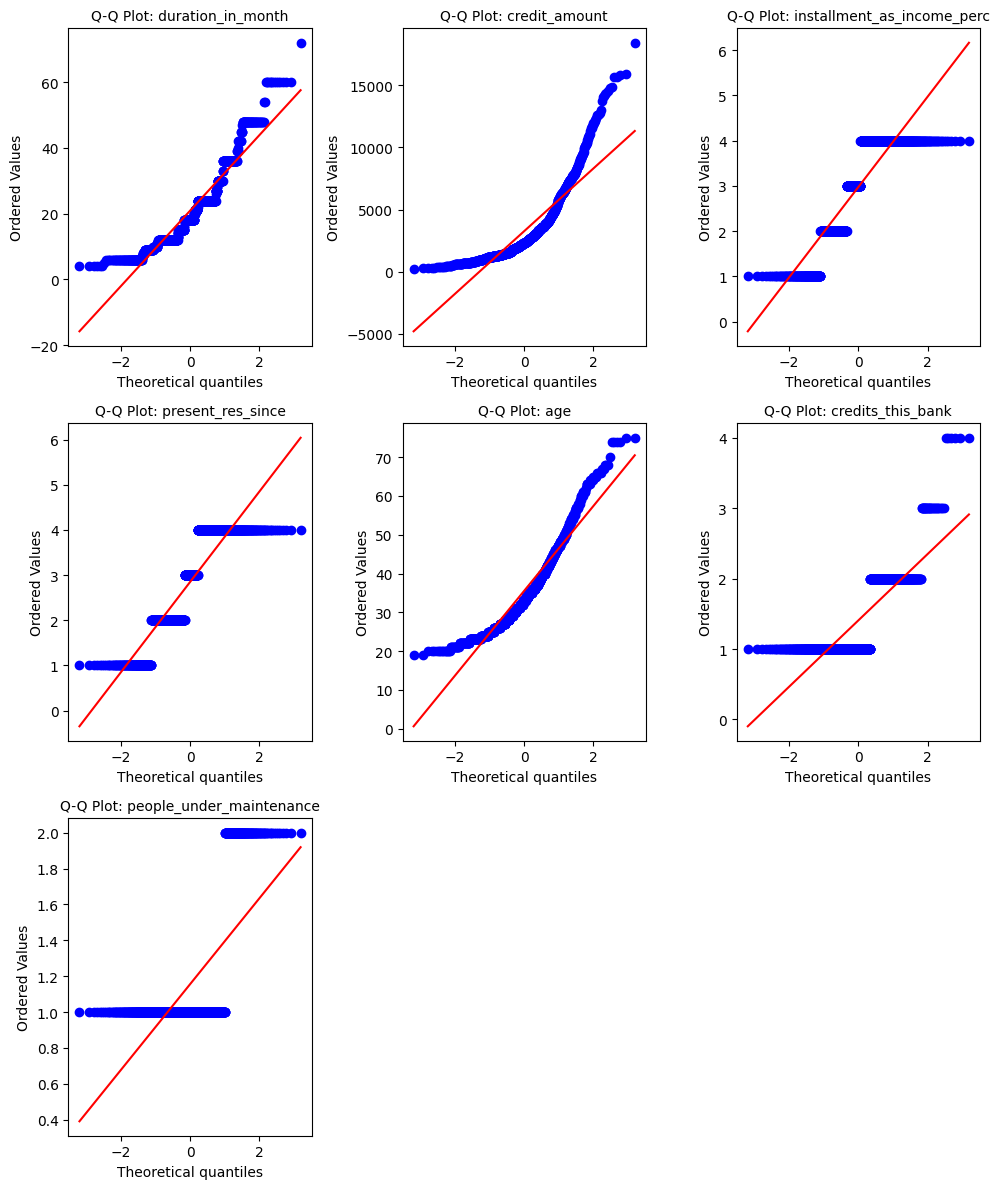

In [80]:
# Crear figura con subplots (3 filas x 3 columnas, sobran casillas)
fig, axes = plt.subplots(3, 3, figsize=(10, 12))

# Aplanar los ejes para iterar fácilmente
axes = axes.flatten()

# Recorrer variables y graficar Q-Q
for i, col in enumerate(numeric_cols):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {col}", fontsize=10)

# Eliminar ejes vacíos (si sobran)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Detección de valores atípicos (outliers)

- Métodos gráficos (boxplot, scatter).

- Métodos estadísticos (z-score, IQR).

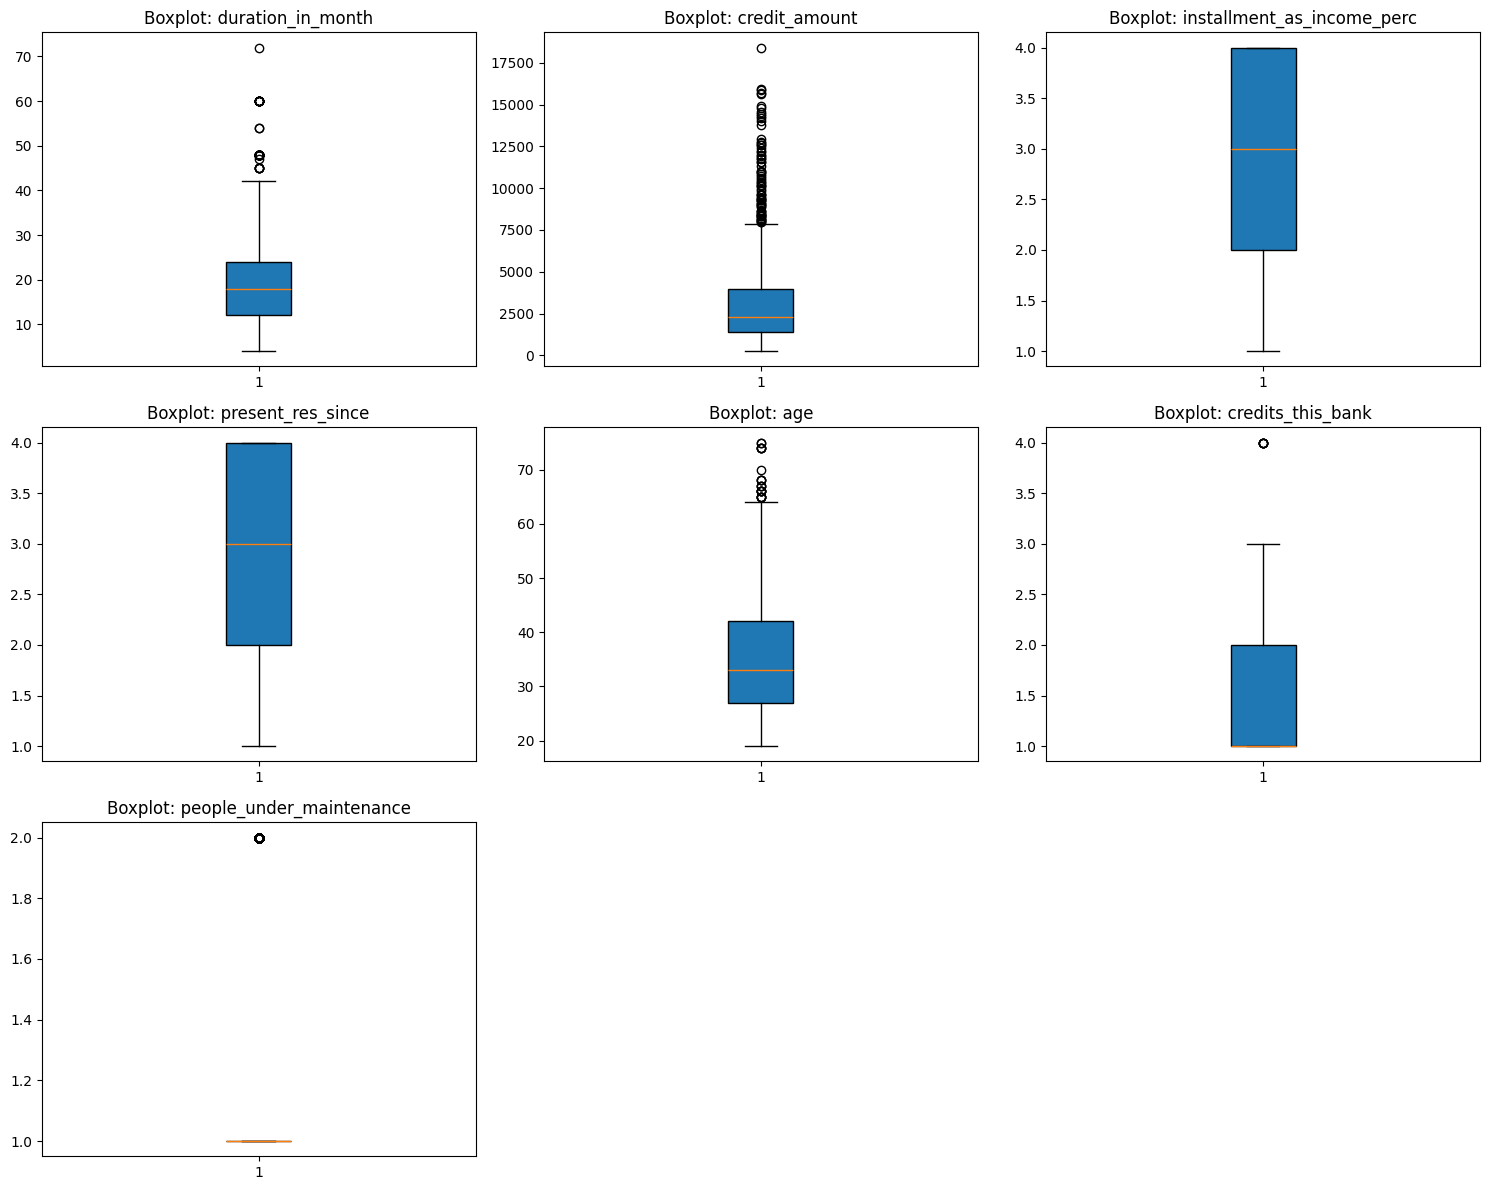

In [81]:
# Crear figura con subplots (3 filas x 3 columnas)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Recorrer columnas y graficar boxplot
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True)
    axes[i].set_title(f"Boxplot: {col}")

# Eliminar ejes vacíos si sobran
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Prueba de Normalidad

In [82]:
from statsmodels.stats.diagnostic import lilliefors

In [83]:
# DataFrame para guardar resultados
normality_results = pd.DataFrame(columns=["Variable", "Shapiro_p", "KS_p", "Dagostino_p"])

for col in numeric_cols:
    data = df[col]

    # Shapiro-Wilk
    shapiro_p = stats.shapiro(data)[1]

    # Kolmogorov-Smirnov (Lilliefors)
    ks_stat, ks_p = lilliefors(data)

    # D’Agostino-Pearson
    dagostino_p = stats.normaltest(data)[1]

    normality_results = pd.concat([
        normality_results,
        pd.DataFrame({
            "Variable": [col],
            "Shapiro_p": [shapiro_p],
            "KS_p": [ks_p],
            "Dagostino_p": [dagostino_p]
        })
    ], ignore_index=True)

print("📊 Resultados de pruebas de normalidad")
print(normality_results)


📊 Resultados de pruebas de normalidad
                     Variable     Shapiro_p   KS_p    Dagostino_p
0           duration_in_month  4.906433e-25  0.001   1.298010e-34
1               credit_amount  8.608546e-34  0.001   1.001233e-86
2  installment_as_income_perc  4.302188e-34  0.001  1.174016e-183
3           present_res_since  1.826854e-32  0.001   0.000000e+00
4                         age  6.382098e-23  0.001   8.442042e-30
5           credits_this_bank  1.257305e-40  0.001   4.800159e-46
6    people_under_maintenance  2.595102e-48  0.001   2.587945e-71


/tmp/ipython-input-4091951810.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  normality_results = pd.concat([



### Resumen de pruebas de normalidad

| Variable                          | Shapiro-Wilk (p) | KS (p) | D’Agostino (p) | Normalidad  |
| --------------------------------- | ---------------- | ------ | -------------- | ----------- |
| **duration\_in\_month**           | 4.9e-25          | 0.001  | 1.3e-34        | ❌ No normal |
| **credit\_amount**                | 8.6e-34          | 0.001  | 1.0e-86        | ❌ No normal |
| **installment\_as\_income\_perc** | 4.3e-34          | 0.001  | 1.2e-183       | ❌ No normal |
| **present\_res\_since**           | 1.8e-32          | 0.001  | 0.0            | ❌ No normal |
| **age**                           | 6.4e-23          | 0.001  | 8.4e-30        | ❌ No normal |
| **credits\_this\_bank**           | 1.3e-40          | 0.001  | 4.8e-46        | ❌ No normal |
| **people\_under\_maintenance**    | 2.6e-48          | 0.001  | 2.6e-71        | ❌ No normal |

---

### Interpretación global

* Todas las pruebas son **estadísticamente significativas** (p < 0.05).
* Conclusión: **ninguna variable sigue una distribución normal**.
* Esto confirma lo que ya vimos en los **Q–Q plots y boxplots**:

  * Variables como `credit_amount` y `duration_in_month` tienen colas largas (outliers).
  * Variables discretas (`installment_as_income_perc`, `credits_this_bank`, `people_under_maintenance`) no pueden ser normales por definición.

## Correlación

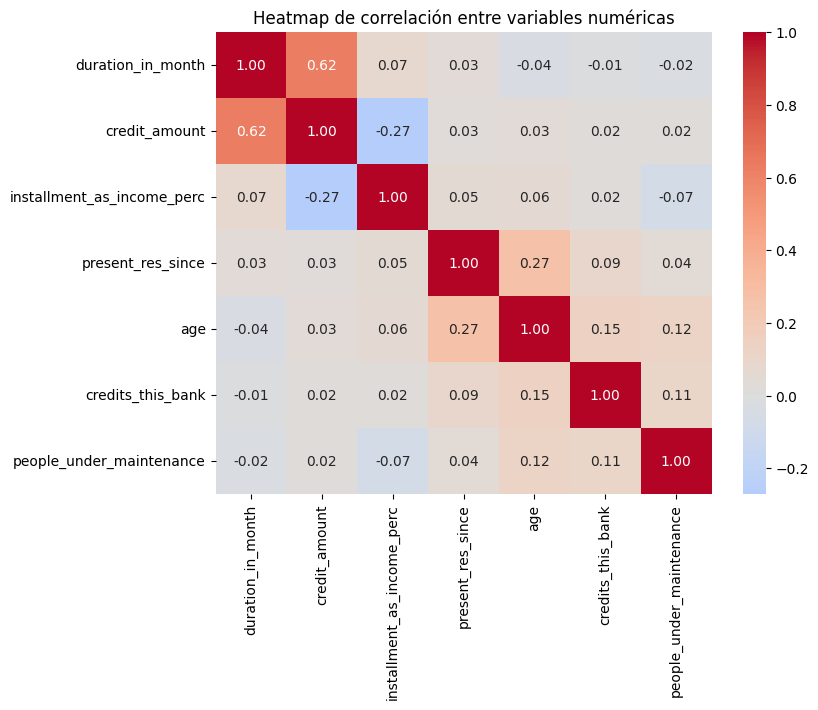

In [84]:
# Calcular matriz de correlación
corr_matrix = df[numeric_cols].corr()

# Crear heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Heatmap de correlación entre variables numéricas")
plt.show()

### Cuadro resumen de correlaciones significativas

| Variables relacionadas                             | Correlación (r) | Interpretación                                                                                                                    |
| -------------------------------------------------- | --------------- | --------------------------------------------------------------------------------------------------------------------------------- |
| **duration\_in\_month ↔ credit\_amount**           | **+0.62**       | Correlación positiva moderada-alta. Los créditos de mayor monto suelen tener mayor duración en meses.                             |
| **credit\_amount ↔ installment\_as\_income\_perc** | **–0.27**       | Correlación negativa débil-moderada. Clientes con cuotas altas respecto a sus ingresos tienden a pedir montos de crédito menores. |
| **age ↔ present\_res\_since**                      | **+0.27**       | Correlación positiva débil-moderada. Personas de mayor edad tienden a permanecer más tiempo en la misma residencia.               |

---

### Conclusión general

* La **relación más fuerte** en el dataset es entre el **monto del crédito y la duración del crédito**, lo que refleja un comportamiento lógico del sistema financiero: créditos más grandes requieren más tiempo para pagarse.
* También aparecen **relaciones débiles-moderadas** con sentido práctico:

  * **Mayor proporción de ingreso destinado a la cuota → montos de crédito más bajos**.
  * **Mayor edad → más estabilidad residencial**.
* El resto de correlaciones son **muy bajas (<0.2)**, lo que confirma que las variables numéricas son **prácticamente independientes** y no presentan problemas de **multicolinealidad**, lo cual es positivo para modelos como regresión logística.

### Pruebas estadísticas de correlación

In [85]:
from itertools import combinations
from scipy.stats import pearsonr, spearmanr, kendalltau

def corr_with_p(x, y, method="pearson"):
    """Devuelve (coeficiente, p-value) eliminando NaNs por pares."""
    xy = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(xy) == 0:
        return np.nan, np.nan
    if method == "pearson":
        r, p = pearsonr(xy["x"], xy["y"])
    elif method == "spearman":
        r, p = spearmanr(xy["x"], xy["y"])
    elif method == "kendall":
        r, p = kendalltau(xy["x"], xy["y"])
    else:
        raise ValueError("Método no reconocido")
    return r, p

# --- Construir cuadro comparativo para todas las parejas (upper triangle) ---
rows = []
for a, b in combinations(numeric_cols, 2):
    r_p, p_p = corr_with_p(df[a], df[b], "pearson")
    r_s, p_s = corr_with_p(df[a], df[b], "spearman")
    r_k, p_k = corr_with_p(df[a], df[b], "kendall")
    rows.append({
        "Var A": a,
        "Var B": b,
        "Pearson r": r_p,     "Pearson p": p_p,
        "Spearman ρ": r_s,    "Spearman p": p_s,
        "Kendall τ": r_k,     "Kendall p": p_k
    })

comp = pd.DataFrame(rows)

# Ordenar por |Spearman| (más robusto en no normalidad), luego |Pearson|
comp["|Spearman|"] = comp["Spearman ρ"].abs()
comp["|Pearson|"]  = comp["Pearson r"].abs()
comp = comp.sort_values(["|Spearman|", "|Pearson|"], ascending=False).drop(columns=["|Spearman|", "|Pearson|"])

# Redondeo para lectura
comp_rounded = comp.copy()
for c in ["Pearson r","Spearman ρ","Kendall τ"]:
    comp_rounded[c] = comp_rounded[c].round(3)
for c in ["Pearson p","Spearman p","Kendall p"]:
    comp_rounded[c] = comp_rounded[c].apply(lambda x: f"{x:.3e}" if pd.notnull(x) else np.nan)

# Mostrar
print("📊 Cuadro comparativo de correlaciones (coeficiente y p-value):")
display(comp_rounded)

# (Opcional) Filtrar solo correlaciones “relevantes” (>|0.25| en Spearman)
filtro = comp.loc[comp["Spearman ρ"].abs() > 0.25]
filtro_rounded = comp_rounded.loc[filtro.index]
print("\n📌 Correlaciones con |Spearman| > 0.25:")
display(filtro_rounded)


📊 Cuadro comparativo de correlaciones (coeficiente y p-value):


,Var A,Var B,Pearson r,Pearson p,Spearman ρ,Spearman p,Kendall τ,Kendall p
0,duration_in_month,credit_amount,0.625,1.863e-109,0.625,2.469e-109,0.466,2.674e-98
6,credit_amount,installment_as_income_perc,-0.271,2.472e-18,-0.313,3.493e-24,-0.239,2.539e-23
15,present_res_since,age,0.266,1.037e-17,0.235,5.557e-14,0.185,2.377e-14
19,age,people_under_maintenance,0.118,1.795e-04,0.191,1.223e-09,0.158,1.682e-09
18,age,credits_this_bank,0.149,2.132e-06,0.141,7.298e-06,0.116,6.656e-06
1,duration_in_month,installment_as_income_perc,0.075,1.807e-02,0.118,1.830e-04,0.094,1.973e-04
20,credits_this_bank,people_under_maintenance,0.110,5.125e-04,0.097,2.140e-03,0.096,2.175e-03
14,installment_as_income_perc,people_under_maintenance,-0.071,2.433e-02,-0.073,2.178e-02,-0.067,2.186e-02
12,installment_as_income_perc,age,0.058,6.551e-02,0.072,2.249e-02,0.055,2.267e-02
16,present_res_since,credits_this_bank,0.090,4.563e-03,0.067,3.362e-02,0.062,3.192e-02



📌 Correlaciones con |Spearman| > 0.25:


,Var A,Var B,Pearson r,Pearson p,Spearman ρ,Spearman p,Kendall τ,Kendall p
0,duration_in_month,credit_amount,0.625,1.863e-109,0.625,2.469e-109,0.466,2.674e-98
6,credit_amount,installment_as_income_perc,-0.271,2.472e-18,-0.313,3.493e-24,-0.239,2.539e-23


#### Conclusiones principales

1. **Correlación más fuerte:**

   * **`duration_in_month` ↔ `credit_amount`**

     * Pearson = 0.625, Spearman = 0.625, Kendall = 0.466
     * p < 0.001 en todas las pruebas.
       ✅ Esto indica una **correlación positiva moderada-alta**: a mayor monto del crédito, mayor suele ser la duración.
     * Es consistente en los tres métodos, lo que refuerza la validez del resultado.

2. **Correlación negativa relevante:**

   * **`credit_amount` ↔ `installment_as_income_perc`**

     * Pearson = –0.271, Spearman = –0.313, Kendall = –0.239
     * p < 0.001 en todas.
       ✅ Existe una **correlación negativa débil-moderada**: quienes destinan un mayor % de su ingreso a la cuota tienden a pedir montos menores.
     * Spearman y Kendall (no paramétricas) la refuerzan → más confiable considerando que los datos no son normales.

3. **Correlación socio-demográfica:**

   * **`present_res_since` ↔ `age`**

     * Pearson = 0.266, Spearman = 0.235, Kendall = 0.185
     * p < 0.001.
       ✅ Relación positiva débil-moderada: personas mayores suelen vivir más tiempo en la misma residencia.

4. **Correlaciones débiles pero significativas:**

   * `age` con `credits_this_bank` (r ≈ 0.14).
   * `age` con `people_under_maintenance` (ρ ≈ 0.19).
   * Estas son **estadísticamente significativas** pero de **magnitud baja**, por lo que no son determinantes en el modelo.

5. **El resto de correlaciones son prácticamente nulas**

   * Ejemplo: `duration_in_month ↔ age` (r ≈ –0.03, p > 0.25).
   * Esto significa que la mayoría de variables numéricas son **independientes**, lo cual es bueno porque **reduce el riesgo de multicolinealidad** en regresión logística.

---

### Interpretación global

* Solo **dos correlaciones destacan** de verdad:

  1. `duration_in_month` con `credit_amount` (positiva, fuerte).
  2. `credit_amount` con `installment_as_income_perc` (negativa, moderada).
* Las demás relaciones son débiles y no comprometen la independencia de variables.
* Los métodos **no paramétricos (Spearman, Kendall)** confirman lo mismo que Pearson, lo cual da robustez a los hallazgos pese a la falta de normalidad en las distribuciones.

### Conclusiones

1. La relación más fuerte encontrada corresponde a la asociación entre **monto del crédito y duración del crédito**, lo cual refleja la lógica del sistema financiero: créditos de mayor cuantía requieren plazos más largos.
2. Existe una relación negativa entre **monto del crédito y proporción de ingreso destinada a la cuota**, lo que sugiere restricciones de riesgo: clientes con alta carga de pago acceden a montos más bajos.
3. Las relaciones socio-demográficas, como **edad y tiempo de residencia**, muestran asociaciones débiles pero coherentes con el comportamiento esperado.
4. El uso de pruebas **no paramétricas (Spearman y Kendall)** confirma la validez de los hallazgos pese a la ausencia de normalidad, fortaleciendo la interpretación.
5. En general, la mayoría de las variables son **prácticamente independientes**, lo cual es positivo para la construcción de modelos predictivos como regresión logística, ya que reduce el riesgo de multicolinealidad.


## Prueba Z-Score

In [86]:
# --- 1. Z-Score ---
# Un valor es outlier si |z| > 3 (umbral clásico)
z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers_z = (z_scores > 3)

print("📊 Detección de outliers con Z-Score (|z| > 3)")
for i, col in enumerate(numeric_cols):
    n_outliers = outliers_z[:, i].sum()
    print(f"{col}: {n_outliers} outliers")

# --- 2. IQR (Rango Intercuartílico) ---
outliers_iqr = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask_outliers = (df[col] < lower) | (df[col] > upper)
    outliers_iqr[col] = mask_outliers.sum()
    print(f"{col}: {outliers_iqr[col]} outliers (IQR)")

# --- 3. Tabla resumen ---
summary_outliers = pd.DataFrame({
    "Variable": numeric_cols,
    "Outliers_ZScore": [outliers_z[:, i].sum() for i in range(len(numeric_cols))],
    "Outliers_IQR": [outliers_iqr[col] for col in numeric_cols]
})

print("\n📊 Resumen de outliers por método:")
print(summary_outliers)


📊 Detección de outliers con Z-Score (|z| > 3)
duration_in_month: 14 outliers
credit_amount: 25 outliers
installment_as_income_perc: 0 outliers
present_res_since: 0 outliers
age: 7 outliers
credits_this_bank: 6 outliers
people_under_maintenance: 0 outliers
duration_in_month: 70 outliers (IQR)
credit_amount: 72 outliers (IQR)
installment_as_income_perc: 0 outliers (IQR)
present_res_since: 0 outliers (IQR)
age: 23 outliers (IQR)
credits_this_bank: 6 outliers (IQR)
people_under_maintenance: 155 outliers (IQR)

📊 Resumen de outliers por método:
                     Variable  Outliers_ZScore  Outliers_IQR
0           duration_in_month               14            70
1               credit_amount               25            72
2  installment_as_income_perc                0             0
3           present_res_since                0             0
4                         age                7            23
5           credits_this_bank                6             6
6    people_under_maintenan

### Resumen de outliers por variable y método

| Variable                          | Outliers (Z-Score, \|z\|>3) | Outliers (IQR, 1.5×IQR) | Interpretación                                                                         |
| --------------------------------- | --------------------------- | ----------------------- | -------------------------------------------------------------------------------------- |
| **duration\_in\_month**           | 14                          | 70                      | IQR detecta más valores extremos → créditos largos (duración ≥ 72 meses).              |
| **credit\_amount**                | 25                          | 72                      | Ambos métodos detectan outliers; IQR capta más debido a montos muy altos (>18.000 DM). |
| **installment\_as\_income\_perc** | 0                           | 0                       | Sin outliers; valores concentrados entre 1 y 4.                                        |
| **present\_res\_since**           | 0                           | 0                       | Sin outliers; variable con rango limitado (1–4 años).                                  |
| **age**                           | 7                           | 23                      | Outliers en clientes de mayor edad (≥ 75). IQR detecta más.                            |
| **credits\_this\_bank**           | 6                           | 6                       | Ambos métodos coinciden: algunos clientes con 3–4 créditos activos.                    |
| **people\_under\_maintenance**    | 0                           | 155                     | El IQR detecta como “outliers” a quienes mantienen a 2 personas (muy pocos casos).     |

---

### Conclusiones

1. **IQR es más sensible** → detecta muchos más outliers, especialmente en variables con valores discretos (`people_under_maintenance`).
2. **Z-Score es más conservador** → detecta menos, solo en variables con colas largas (`credit_amount`, `duration_in_month`).
3. En datos financieros como German Credit, **ambos métodos coinciden en las variables más críticas**:

   * `credit_amount` (montos de crédito).
   * `duration_in_month` (tiempo del crédito).
   * `age` (clientes muy mayores).

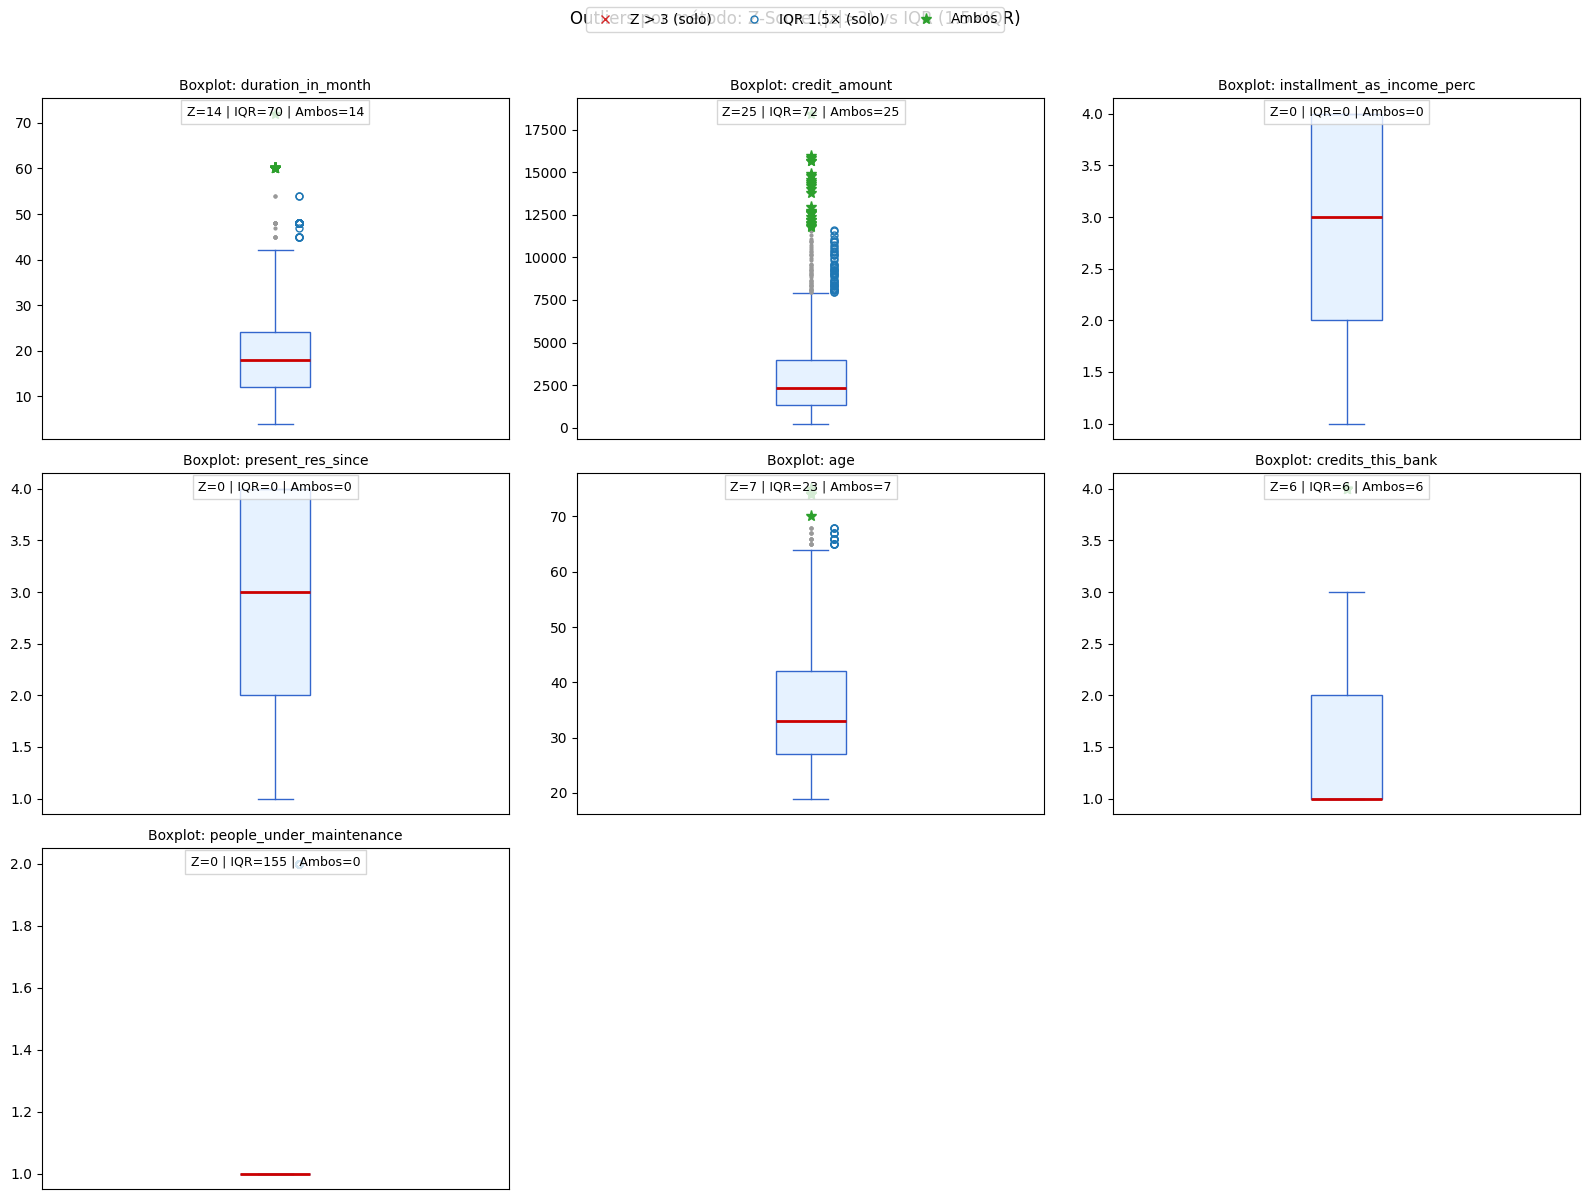

In [87]:
# === 2) Funciones auxiliares ===
def zscore_outliers(series, thr=3.0):
    """Máscara booleana de outliers por |z| > thr."""
    z = np.abs(stats.zscore(series, nan_policy="omit"))
    return z > thr

def iqr_outliers(series, k=1.5):
    """Máscara booleana de outliers por IQR (Q1 - k*IQR, Q3 + k*IQR)."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)

# === 3) Crear figura en rejilla ===
n = len(numeric_cols)
rows = 3
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

# Estilo de marcadores para los tres casos
style_z_only   = dict(marker='x', linestyle='None', markersize=6)
style_iqr_only = dict(marker='o', linestyle='None', markersize=5, fillstyle='none')
style_both     = dict(marker='*', linestyle='None', markersize=8)

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    y = df[col].values

    # --- Boxplot base ---
    bp = ax.boxplot(y, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#e6f2ff", edgecolor="#3366cc"),
                    medianprops=dict(color="#cc0000", linewidth=2),
                    whiskerprops=dict(color="#3366cc"),
                    capprops=dict(color="#3366cc"),
                    flierprops=dict(marker='.', markersize=4, markerfacecolor="#999999", markeredgecolor="#999999"))

    ax.set_title(f"Boxplot: {col}", fontsize=10)
    ax.set_xticks([])

    # --- Cálculo de máscaras ---
    mask_z   = zscore_outliers(df[col])
    mask_iqr = iqr_outliers(df[col])
    mask_both = mask_z & mask_iqr
    mask_z_only = mask_z & ~mask_iqr
    mask_iqr_only = mask_iqr & ~mask_z

    # --- Dispersión para resaltar outliers ---
    # Todos en x=1, con ligeros desplazamientos para no superponer
    x_base = 1.0
    ax.plot(np.full(mask_z_only.sum(),  x_base - 0.05), y[mask_z_only],  **style_z_only,   color="#d62728", label="Z > 3 (solo)" if i==0 else None)
    ax.plot(np.full(mask_iqr_only.sum(),x_base + 0.05), y[mask_iqr_only],**style_iqr_only, color="#1f77b4", label="IQR 1.5× (solo)" if i==0 else None)
    ax.plot(np.full(mask_both.sum(),    x_base),        y[mask_both],    **style_both,     color="#2ca02c", label="Ambos" if i==0 else None)

    # --- Texto con conteos ---
    tz, ti, tb = int(mask_z.sum()), int(mask_iqr.sum()), int(mask_both.sum())
    ax.text(0.5, 0.98, f"Z={tz} | IQR={ti} | Ambos={tb}",
            transform=ax.transAxes, ha="center", va="top", fontsize=9, bbox=dict(facecolor="white", alpha=0.8, edgecolor="#cccccc"))

# Eliminar ejes sobrantes si los hay
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("Outliers por método: Z-Score (|z|>3) vs IQR (1.5×IQR)", y=0.995, fontsize=12)

# Guardar si quieres
# plt.savefig("outliers_resumen_boxplots.png", dpi=160, bbox_inches="tight")

plt.show()

#### Cómo leer cada subplot

* **Caja**: rango intercuartílico (IQR).
* **Línea roja**: mediana.
* **Puntos**:

  * **x rojas** → outliers **solo Z-Score**
  * **o azules** (huecos) → outliers **solo IQR**
  * **★ verdes** → outliers **en ambos métodos**
* **Etiqueta superior**: `Z=… | IQR=… | Ambos=…` del **columna** correspondiente.

Si quieres, adapto el umbral (por ejemplo **Z>|2.5|** o **IQR=3×**) y te muestro cómo cambian los resultados.



## Preprocesamiento preliminar

- Normalización o estandarización de variables (cuando se requiere).

- Codificación de variables categóricas (Label/One-hot).

### Evidencias del análisis

1. **Normalidad:**

   * Todas las variables numéricas rechazaron la hipótesis de normalidad (Shapiro, KS y D’Agostino con p < 0.05).
   * Los Q–Q plots confirmaron distribuciones sesgadas (ej. `credit_amount`, `duration_in_month`) o discretas (`installment_as_income_perc`, `credits_this_bank`).

2. **Outliers:**

   * Métodos Z-Score e IQR mostraron que existen **outliers significativos**, sobre todo en `credit_amount`, `duration_in_month` y `people_under_maintenance`.
   * Estos outliers afectan mucho a las medias y desviaciones estándar.

3. **Correlaciones:**

   * No hay multicolinealidad fuerte; solo relaciones lógicas (ej. monto–duración).
   * Pero como los datos no son normales y presentan colas largas, los métodos paramétricos (como Pearson) deben interpretarse con cautela.

4. **Escalas diferentes:**

   * Variables como `credit_amount` (miles de DM) tienen un rango mucho mayor que `credits_this_bank` (1–4) o `people_under_maintenance` (1–2).
   * Esto puede generar sesgo en algoritmos sensibles a magnitud (ej. K-means, regresión logística regularizada, SVM, redes neuronales).

---

### Conclusión

Dado que:

* Las variables **no son normales**.
* Existen **outliers importantes**.
* Hay **diferencias de escala** entre variables.

La mejor opción **no es una simple normalización min-max**, porque se vería muy afectada por outliers (ejemplo: un solo crédito de 18.000 DM distorsionaría el rango).

👉 Lo más recomendable es aplicar **estandarización robusta**:

* **StandardScaler** (media=0, varianza=1) → si decides mantener outliers y trabajas con modelos que toleran dispersión.
* **RobustScaler** (usa mediana e IQR en vez de media y desviación estándar) → ideal en tu caso, porque reduce el impacto de los outliers.

En resumen:

* Si vas a usar **modelos lineales (ej. regresión logística)** → aplica **estandarización**.
* Si vas a usar **modelos sensibles a distancias (K-means, SVM, PCA, redes neuronales)** → aplica **RobustScaler o MinMaxScaler**, pero prefiriendo RobustScaler por los outliers.
* **Normalización simple** no es recomendable en este dataset.

### ¿Es necesario aplicar PCA u otra técnica de reducción de dimensionalidad?

#### 1. **Número de variables**

El dataset *German Credit* tiene solo **7 variables numéricas** y **13 categóricas** (que se expanden al codificarlas). Esto no es “alta dimensionalidad” como para justificar PCA por carga computacional.

#### 2. **Multicolinealidad**

* Tu análisis mostró **baja correlación entre la mayoría de variables**.
* Solo destaca la correlación fuerte entre `duration_in_month` y `credit_amount` (r ≈ 0.62).
* Esto **no es suficiente para justificar PCA**, ya que la multicolinealidad no es crítica.

#### 3. **Interpretabilidad**

* PCA transforma las variables en combinaciones lineales (componentes principales).
* Esto reduce la interpretabilidad, lo cual es negativo si quieres entender qué variable influye en el **riesgo de crédito (default)**.

#### 4. **Alternativas más útiles que PCA en tu caso**

* **Estandarización robusta (RobustScaler)** de numéricas → para mitigar outliers.
* **Codificación de categóricas (One-Hot o Label)** → para usarlas en modelos supervisados.
* **Regularización (L1 o L2)** en la regresión logística → ayuda a manejar multicolinealidad sin perder interpretabilidad.
* **Selección de variables** (ej. ANOVA, Chi-cuadrado, o modelos basados en importancia de características) → más informativo que PCA.

---

## Conclusión

No es necesario aplicar **PCA** en este dataset porque:

* No hay alta dimensionalidad.
* La multicolinealidad es baja.
* La interpretabilidad es importante en un problema de riesgo crediticio.

Lo que sí debes aplicar es:

1. **Estandarización robusta** de numéricas.
2. **Codificación adecuada** de categóricas.
3. **Regularización** en la regresión logística para estabilizar coeficientes.

Con esto, tus variables estarán listas para el modelado sin necesidad de PCA.


### Cuadro resumen de acciones a realizar

| Etapa                                     | Acción recomendada                                                            | Justificación                                                                                                                                        | Herramienta sugerida                             |
| ----------------------------------------- | ----------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------ |
| **1. Variables numéricas**                | Aplicar **Estandarización robusta (RobustScaler)**                            | Las variables no son normales y tienen outliers. El RobustScaler usa mediana e IQR, evitando que los valores extremos distorsionen la escala.        | `sklearn.preprocessing.RobustScaler`             |
| **2. Variables categóricas**              | Realizar **codificación One-Hot (OHE)** o **Label Encoding** según el modelo  | Necesario para convertir variables categóricas a formato numérico. Para regresión logística y SVM es mejor One-Hot; para árboles puede bastar Label. | `sklearn.preprocessing.OneHotEncoder`            |
| **3. Outliers**                           | Mantenerlos, pero controlar su efecto con RobustScaler                        | Eliminar outliers en finanzas puede borrar información valiosa. Mejor mitigarlos que quitarlos.                                                      | Controlado indirectamente con RobustScaler       |
| **4. Normalización vs Estandarización**   | **No usar Min-Max (normalización simple)** → preferir estandarización robusta | Min-Max es muy sensible a outliers (ejemplo: créditos de 18.000 DM).                                                                                 | `RobustScaler`                                   |
| **5. Reducción de dimensionalidad (PCA)** | **No aplicar PCA**                                                            | El dataset no es de alta dimensión, la multicolinealidad es baja y se necesita interpretabilidad.                                                    | —                                                |
| **6. Regularización**                     | Usar **regresión logística con regularización (L1/L2)**                       | Permite estabilizar coeficientes y manejar correlaciones moderadas (`credit_amount`–`duration_in_month`).                                            | `sklearn.linear_model.LogisticRegression`        |
| **7. Pipeline de preprocesamiento**       | Construir un **pipeline integrado (numéricas + categóricas + modelo)**        | Permite tener un flujo reproducible y evitar fugas de datos.                                                                                         | `sklearn.pipeline.Pipeline`, `ColumnTransformer` |

---

### Síntesis

* No necesitas PCA.
* Debes usar **RobustScaler + OneHotEncoder** como preprocesamiento base.
* Añadir **regularización en la regresión logística** será suficiente para controlar correlaciones y mejorar estabilidad del modelo.

## Cuadro comparativo de preprocesamiento por modelo de ML

| Modelo                                            | Preprocesamiento numéricas                                                | Preprocesamiento categóricas          | Tratamiento de outliers                                    | Muestreo estratificado (¿Sí/No?) + Variable recomendada                                                      | Observaciones                                                                  |
| ------------------------------------------------- | ------------------------------------------------------------------------- | ------------------------------------- | ---------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------ |
| **Regresión logística**                           | RobustScaler (para estabilidad)                                           | One-Hot Encoding (OHE)                | Mantener, controlar con RobustScaler                       | ✅ Sí → `default` (variable objetivo, balance de clases)                                                      | Requiere regularización (L1/L2) para mejorar estabilidad y evitar sobreajuste. |
| **Regresión lineal**                              | RobustScaler (para mitigar outliers)                                      | OHE (si hay categóricas explicativas) | Outliers afectan mucho, considerar Winsorización           | ✅ Sí → `default` (si es binaria la salida) o segmentación por `job`/`personal_status_sex` si es exploratorio | Menos usada en clasificación, útil como modelo base en regresión continua.     |
| **Regresión polinómica**                          | RobustScaler o StandardScaler (importante para estabilidad en polinomios) | OHE                                   | Outliers distorsionan fuertemente los términos polinómicos | ✅ Sí → `default` o `personal_status_sex`                                                                     | Puede capturar relaciones no lineales, pero riesgo alto de sobreajuste.        |
| **Árboles de decisión / Random Forest / XGBoost** | No requiere escalado                                                      | Label Encoding u OHE                  | No sensibles a outliers                                    | ⚠️ Opcional, pero útil → `default`                                                                           | Árboles dividen por valores, no requieren normalización.                       |
| **K-Means / KNN / SVM (distancia)**               | RobustScaler o MinMaxScaler (mejor Robust)                                | OHE obligatorio                       | Sí, afectan distancias → mitigar con escalado              | ✅ Sí → `default` o `personal_status_sex` (balance hombres/mujeres)                                           | Sensibles a escalas; KNN/KMeans distorsionan si no hay escalado correcto.      |
| **Redes neuronales**                              | MinMaxScaler \[0,1] o StandardScaler                                      | OHE indispensable                     | Se recomienda controlar con MinMax                         | ✅ Sí → `default` o `savings` (categoría de ahorro)                                                           | Sensibles a escalas, normalizar es obligatorio.                                |
| **PCA (exploratorio)**                            | StandardScaler (obligatorio antes de PCA)                                 | OHE antes de aplicar PCA              | Outliers afectan PCA → usar RobustScaler                   | ⚠️ Opcional, no necesario en este dataset                                                                    | Reduce dimensionalidad, pero se pierde interpretabilidad.                      |

---

## Conclusiones prácticas

* El **muestreo estratificado es altamente recomendable** en este dataset porque la variable objetivo `default` (riesgo crediticio) suele estar desbalanceada.
* Si se quisiera estratificar en variables explicativas, las más útiles serían **`personal_status_sex` (sexo/estado civil)** y **`savings` (nivel de ahorro)**, porque dividen poblaciones en grupos relevantes para el crédito.
* Para **modelos lineales y polinómicos**, el escalado robusto es crítico (sensibles a outliers).
* Para **modelos basados en distancia y redes neuronales**, el escalado es obligatorio (RobustScaler o MinMaxScaler).
* Para **árboles**, no es necesario el escalado ni el muestreo estratificado, aunque estratificar puede ayudar en entrenamiento/test para mantener balance.

## Muestreo estratificado

### Analisis variables categóricas

- Si una variable tiene categorías equilibradas (buen candidato para estratificar).

- Si está muy desbalanceada (estratificar podría causar problemas en algunos folds).

- Si la variable es continua, cómo se distribuye (se pueden crear bins/cuartiles para estratificar).

In [88]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Columnas categóricas:", cat_cols)

Columnas categóricas: ['account_check_status', 'credit_history', 'purpose', 'savings', 'present_emp_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker', 'sex', 'marital_status']


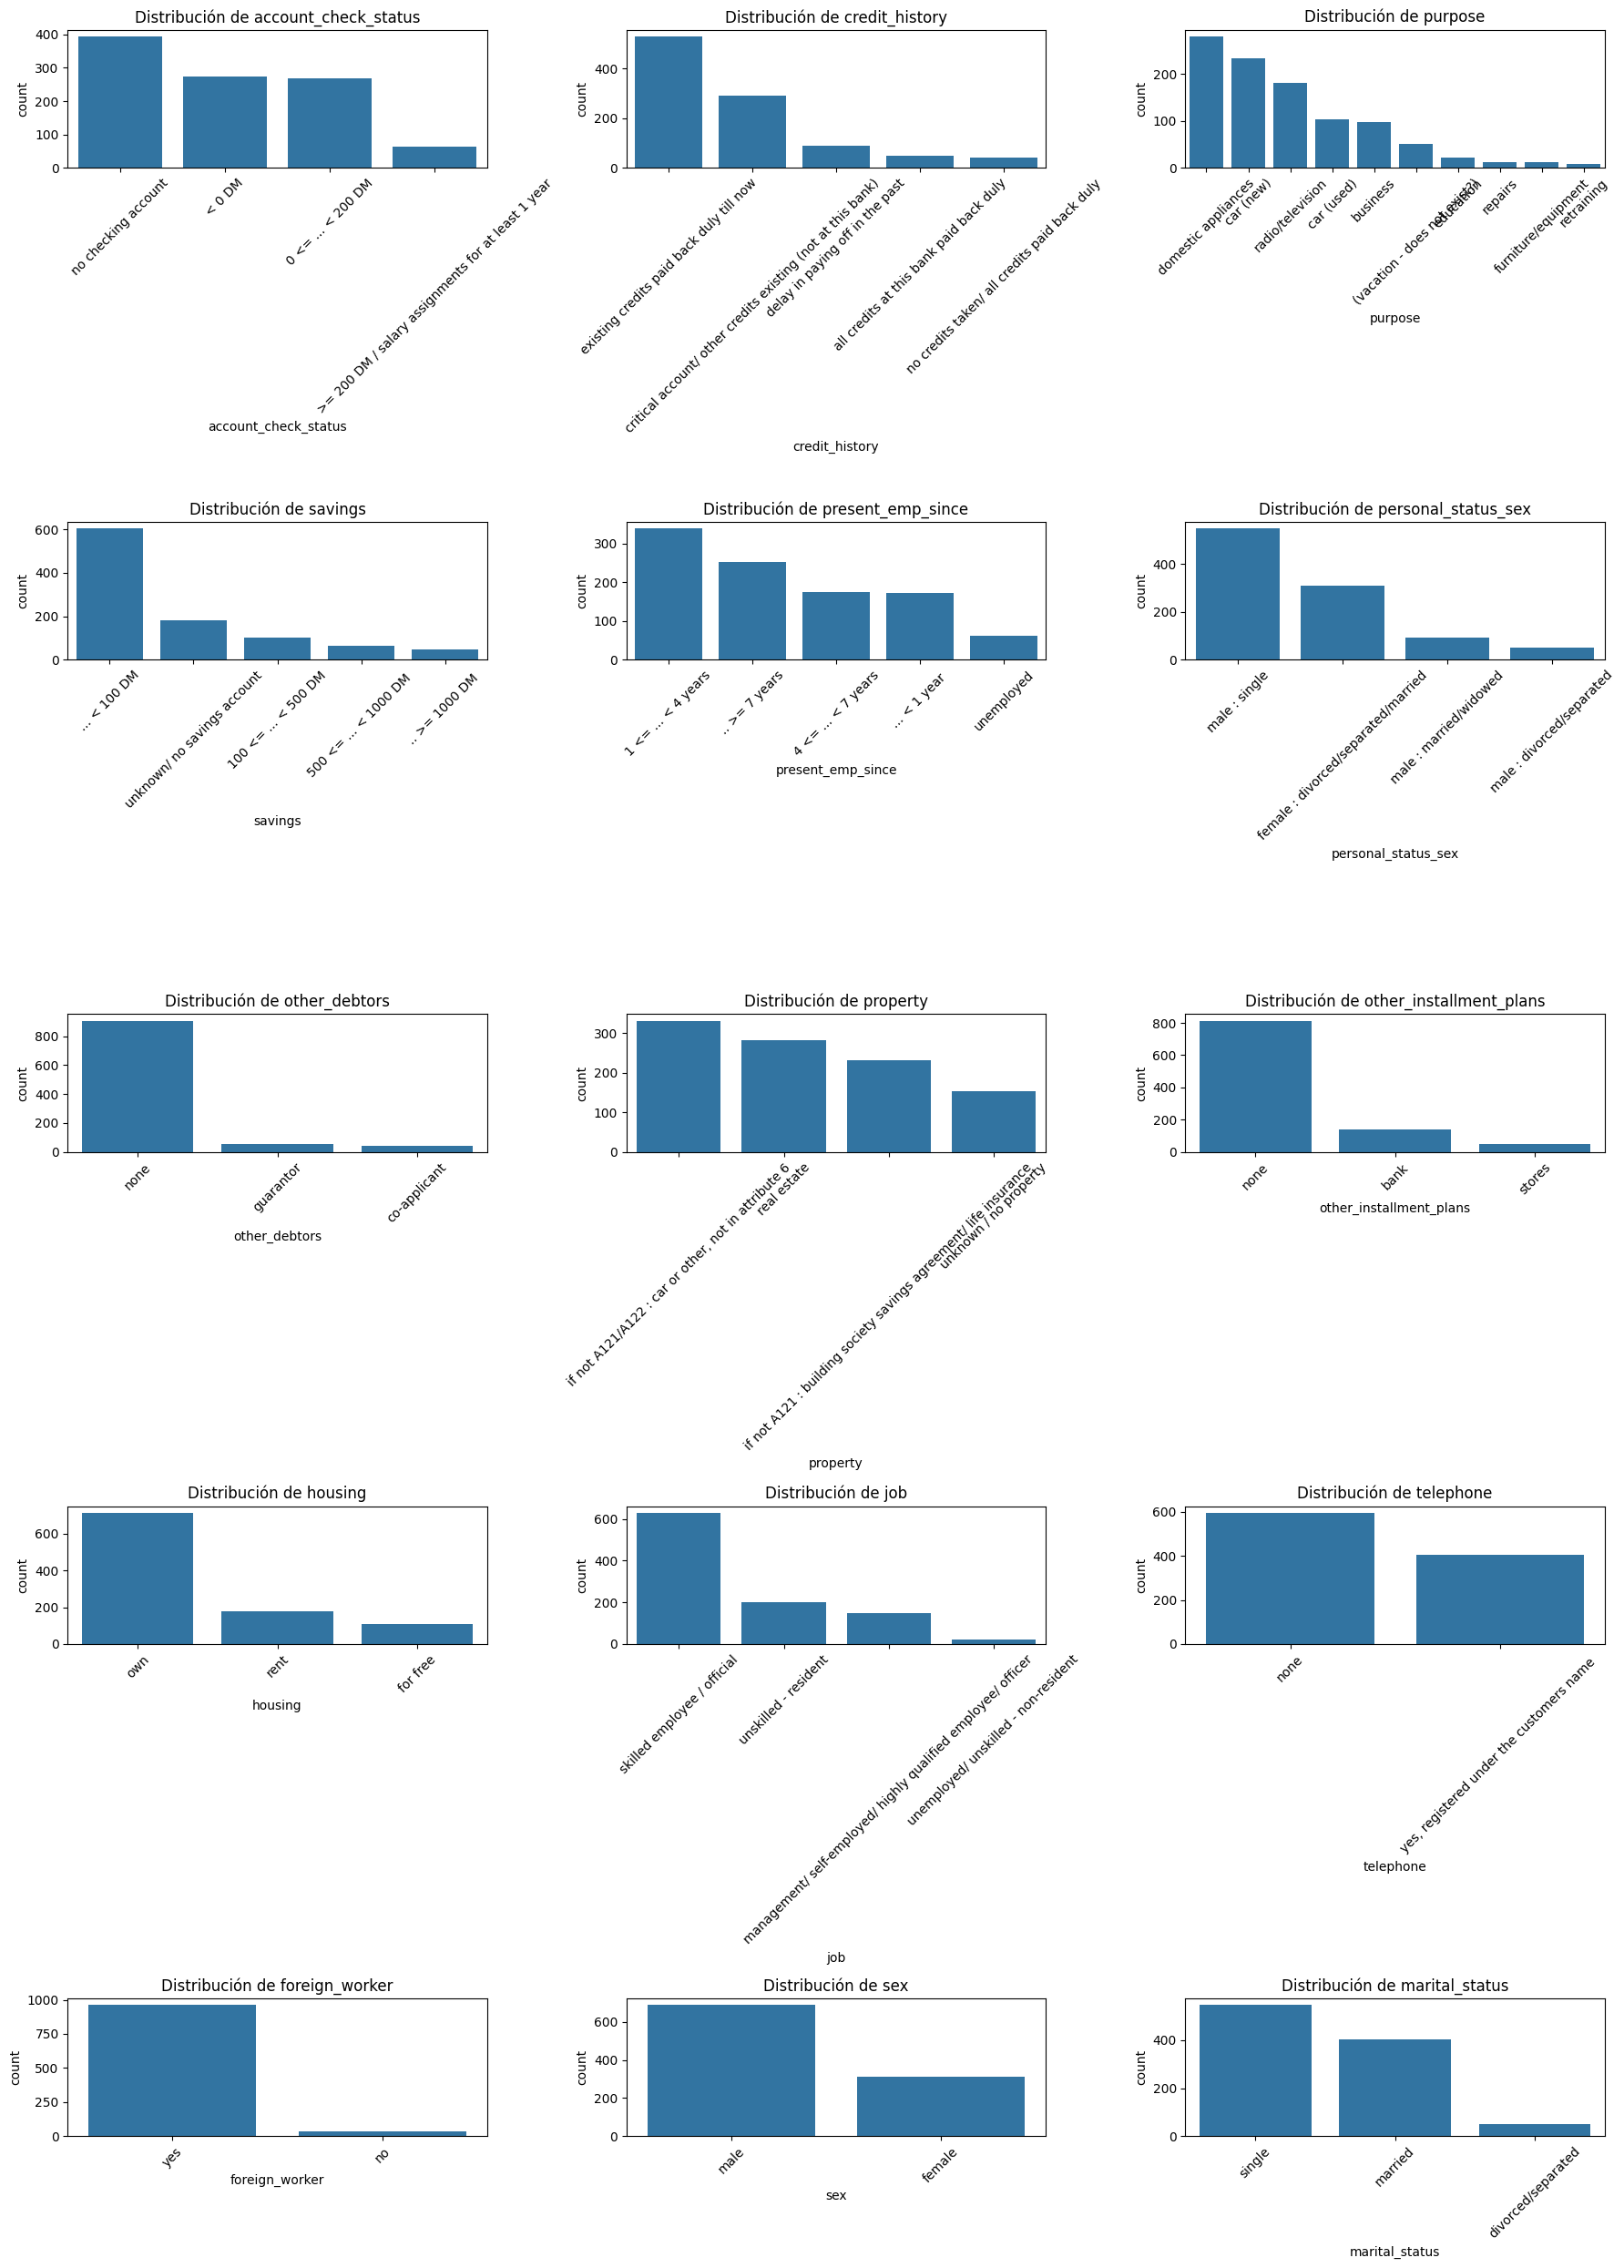

In [89]:
# Crear figura con subplots
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18,25)) # Increased rows to accommodate all categorical columns
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar subplot vacío if sobra (because there are 15 categorical columns and 15 axes)
if len(cat_cols) < len(axes):
    for j in range(len(cat_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Analisis variables numéricas

- Graficar histogramas o boxplots para ver su dispersión.

- Se debe transformar en bins (ej. cuartiles).

In [90]:
# Detectar columnas numéricas (int64, float64)
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("Columnas numéricas:", num_cols)

Columnas numéricas: ['default', 'duration_in_month', 'credit_amount', 'installment_as_income_perc', 'present_res_since', 'age', 'credits_this_bank', 'people_under_maintenance']


#### Histogramas (distribución de valores)


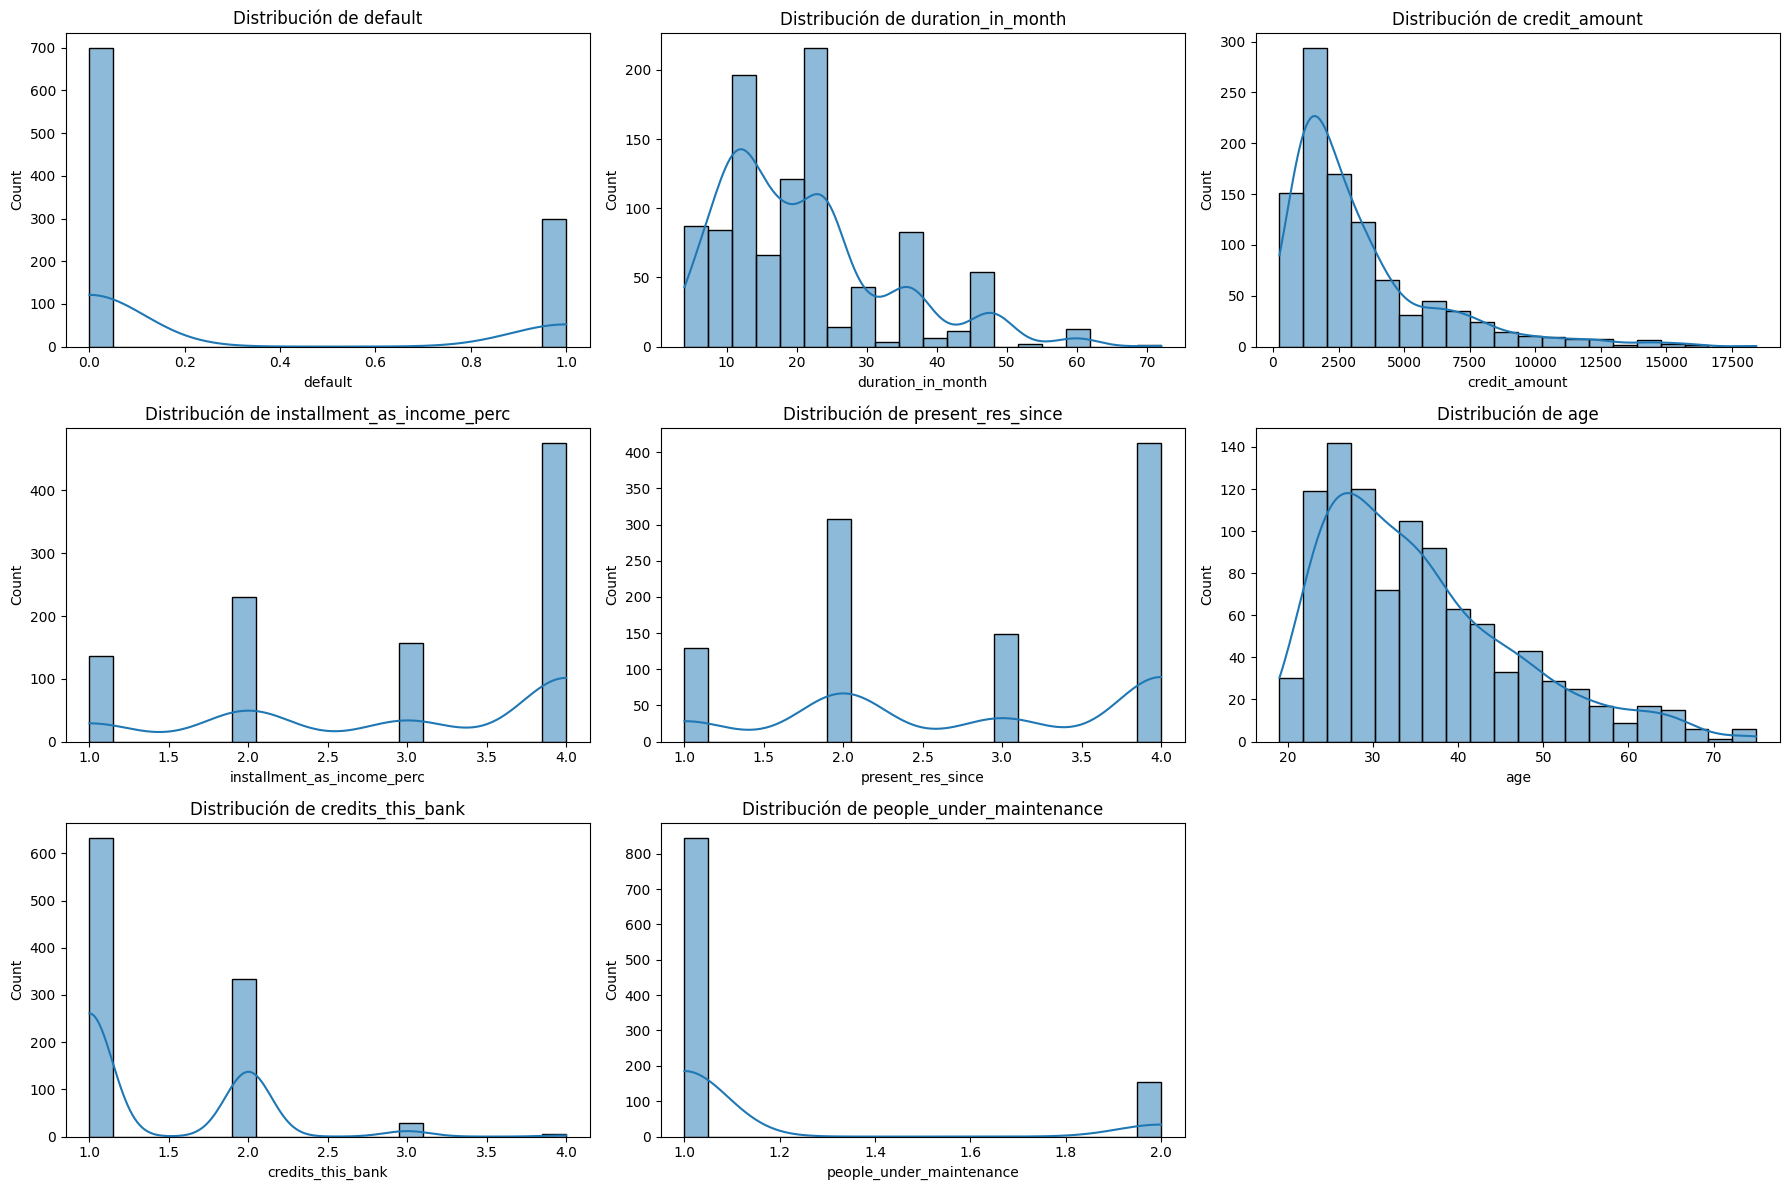

In [91]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")

# Eliminar subplots vacíos si sobran
if len(num_cols) < len(axes):
    for j in range(len(num_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Boxplots (detectar outliers)

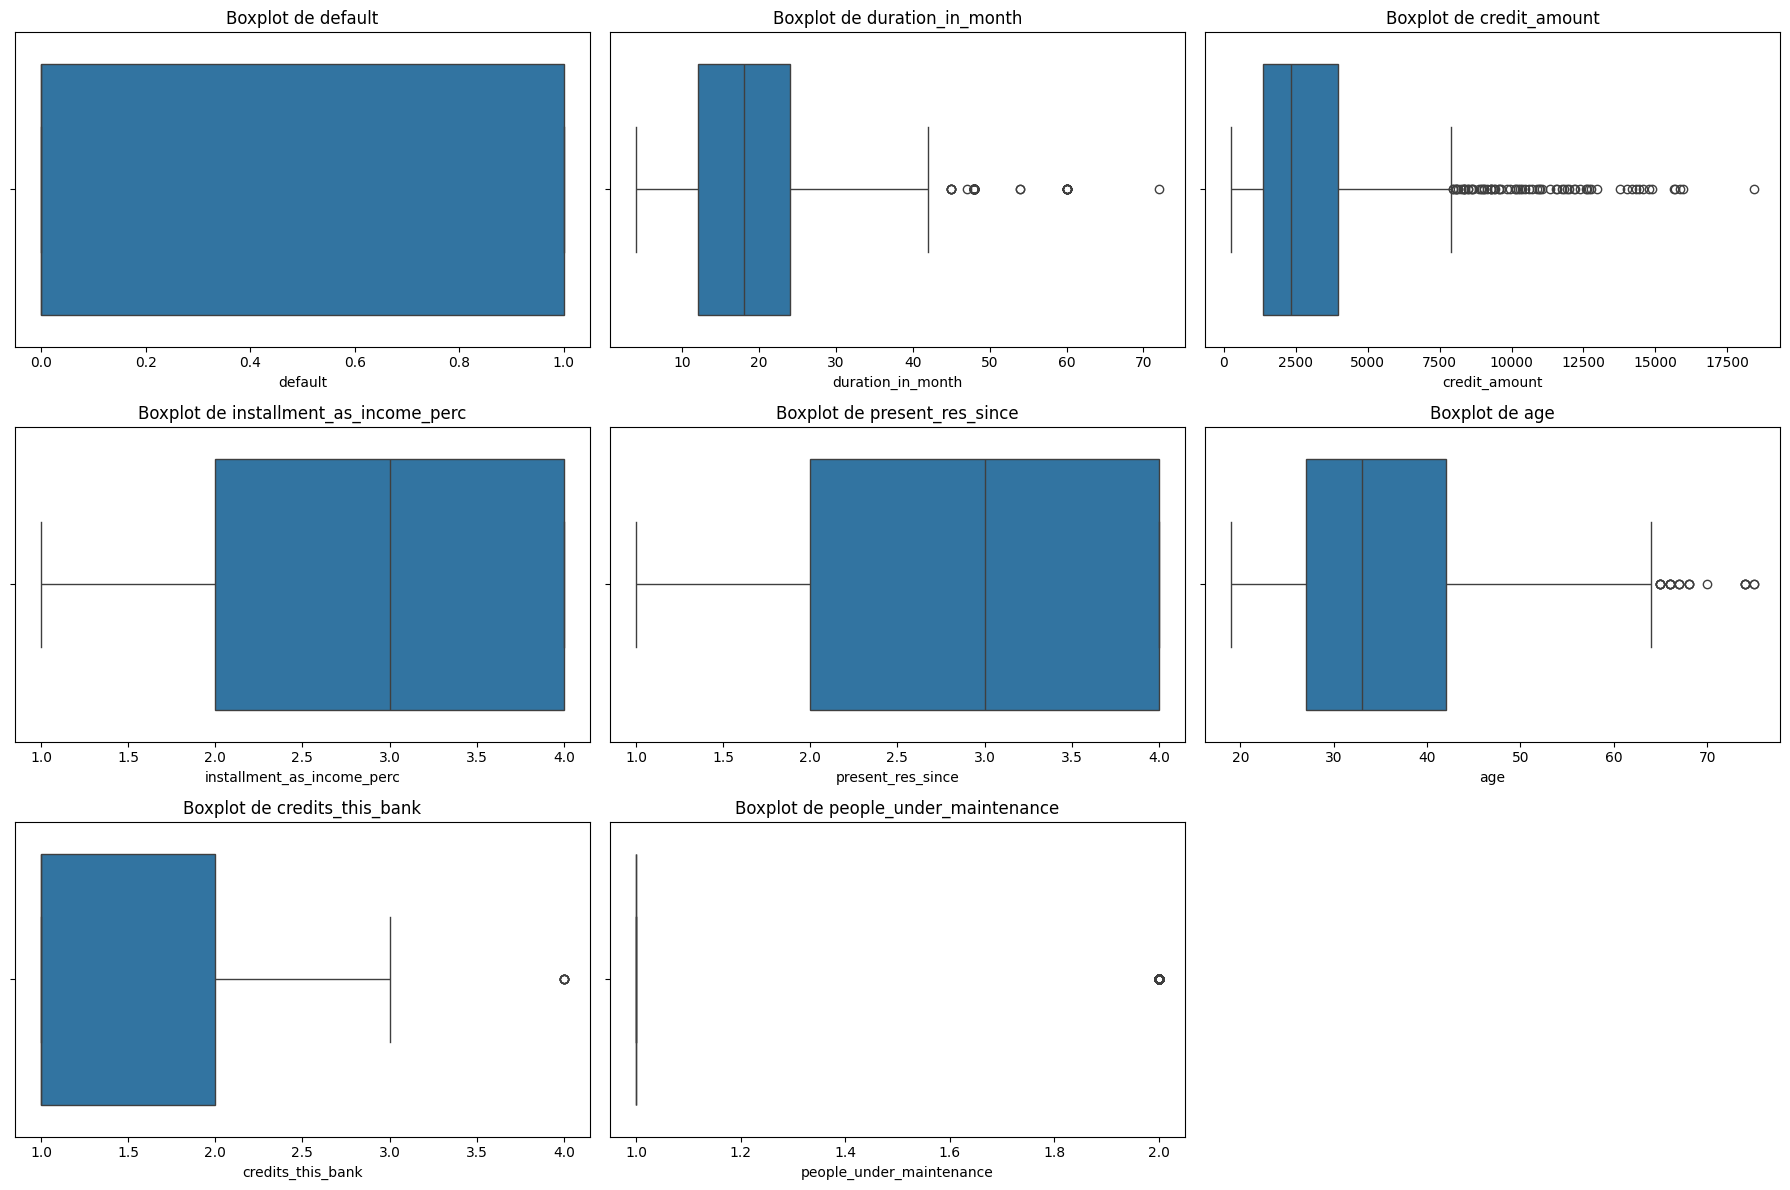

In [92]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")

if len(num_cols) < len(axes):
    for j in range(len(num_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Conclusiones de muestreo estratificado

#### Caso **Clasificación** (target = `default`)

* **La mejor variable para estratificar es directamente `default`**.

  * Tu gráfico mostró que está **desbalanceada** (aprox. 70% clase 0, 30% clase 1).
  * Si no estratificas, corres el riesgo de que en un fold falten muestras de la clase minoritaria.

Recomendación:

```python
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
```

Así mantienes la proporción **0/1 de `default`** en todos los folds.

#### Caso **Regresión** (target = `credit_amount` o `duration_in_month`)

Aquí no puedes estratificar directamente porque el target es continuo.
Pero puedes crear **bins artificiales** para garantizar que los folds representen bien toda la distribución:

* `credit_amount` → lo viste sesgado, con **muchos valores bajos y pocos muy altos**.

  * Se recomienda **estratificar en cuartiles o quintiles** (ejemplo: bajos, medios, altos, muy altos).

* `duration_in_month` → tiene picos en valores redondos (12, 24, 36 meses).

  * Puedes estratificar en bins de duración (ejemplo: corto ≤12, medio 13–24, largo >24).

 Ejemplo en código:

```python
import numpy as np
from sklearn.model_selection import StratifiedKFold

# Crear bins de credit_amount en cuartiles
df['credit_bins'] = pd.qcut(df['credit_amount'], q=4, labels=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
```


#### Variables categóricas adicionales

De las categóricas que graficaste:

* **`personal_status_sex`**: tiene suficiente variación (hombres/solteros predominan, pero hay varias categorías).
* **`savings`**: muy desbalanceada (la mayoría <100 DM).
* **`job`**: también desbalanceada (empleados calificados dominan).

👉 **No recomiendo usarlas como base de estratificación principal**, porque forzarían algunos folds con muy pocas muestras de ciertas categorías → perderías estabilidad.

Sí puedes usarlas como **criterios secundarios de análisis** (por ejemplo: comparar métricas por subgrupos).


#### Conclusión

1. **Clasificación (riesgo de default):**

   * Estratificar **siempre por `default`** (variable objetivo).

2. **Regresión (predicción de montos o duración):**

   * Estratificar creando **bins del target continuo**:

     * `credit_amount` → cuartiles o quintiles.
     * `duration_in_month` → grupos de meses (ej. corto, medio, largo).

3. **Otras categóricas (`personal_status_sex`, `savings`, `job`)**

   * No son recomendables como criterio de estratificación principal porque están desbalanceadas.
   * Se pueden usar solo para análisis post-modelo.

Con toda la evidencia y conclusiones anteriores (normalidad, outliers, escalado, PCA, distribución de variables, etc.), aquí te armo un **cuadro comparativo** con lo que conviene hacer **según el tipo de modelo de ML**, indicando:

1. Qué **variables estratificar sí o sí**.
2. Qué **otras variables conviene evaluar** en cada modelo (pero no necesariamente estratificar).
3. Observaciones clave de preprocesamiento.

---

### Cuadro comparativo de estrategias por modelo

| Tipo de modelo                                                                              | Estratificación obligatoria                                                        | Variables recomendadas para evaluar                                                                                                  | Preprocesamiento clave                                 | Observaciones                                                                   |
| ------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------ | ------------------------------------------------------------------------------- |
| **Clasificación (Regresión Logística, SVM, KNN, Redes Neuronales, XGBoost, Random Forest)** | **`default`** (para mantener proporción 0/1)                                       | `personal_status_sex`, `credit_history`, `savings`, `job`, `housing` (todas categóricas con posible influencia en riesgo crediticio) | **RobustScaler** en numéricas + **OHE** en categóricas | Regularización (L1/L2 en logística, C en SVM), cuidado con outliers en KNN/SVM. |
| **Árboles de clasificación (DecisionTree, Random Forest, XGBoost)**                         | **`default`**                                                                      | Todas las categóricas (árboles manejan relaciones no lineales y categorías bien). Numéricas sin escalado.                            | Label Encoding u OHE (ambos sirven)                    | Escalado no necesario. Outliers no afectan tanto.                               |
| **Regresión lineal (predicción de `credit_amount` o `duration_in_month`)**                  | **Bins del target** (`credit_amount` en cuartiles / `duration_in_month` en grupos) | `age`, `present_emp_since`, `savings`, `job`                                                                                         | **RobustScaler** (afecta mucho a la linealidad)        | Sensible a outliers, considerar Winsorización o regularización Ridge/Lasso.     |
| **Regresión polinómica**                                                                    | **Bins del target** (`credit_amount` o `duration_in_month`)                        | Igual que lineal, pero incluir interacciones de `age`, `duration_in_month`, `credit_amount`                                          | **StandardScaler o RobustScaler**                      | Riesgo alto de sobreajuste, aplicar regularización y validación estricta.       |
| **Árboles de regresión (DecisionTreeRegressor, RandomForestRegressor, XGBRegressor)**       | **Bins del target continuo** (igual que arriba)                                    | Todas las categóricas + numéricas crudas                                                                                             | Label Encoding suficiente                              | Escalado no necesario, manejan outliers mejor que modelos lineales.             |
| **Modelos de distancia (KMeans, KNN, SVM regresión - SVR)**                                 | **Bins del target (si regresión)** o `default` (si clasificación)                  | Numéricas escaladas + OHE en categóricas                                                                                             | **RobustScaler o MinMaxScaler**                        | Extremadamente sensibles a escalas → escalado crítico.                          |
| **Redes neuronales (clasificación/regresión)**                                              | **Siempre** estratificar (`default` o bins target)                                 | Todas (numéricas escaladas + categóricas OHE)                                                                                        | **MinMaxScaler \[0,1]**                                | Normalización necesaria para la estabilidad de optimización.                    |

---

### Conclusión clara por caso

* **Si clasificas riesgo de crédito (`default`)** → estratificar siempre por **`default`**.
* **Si predices un valor continuo (`credit_amount`, `duration_in_month`)** → estratificar en **bins del target** (cuartiles/quintiles o grupos).
* **Variables adicionales (`personal_status_sex`, `savings`, `job`, `housing`)** → no estratificar, pero sí evaluar como predictoras importantes.
* **Escalado**:

  * **RobustScaler** → casi todos los modelos sensibles a magnitud (logística, KNN, SVM).
  * **MinMaxScaler** → redes neuronales.
  * **Sin escalado** → árboles.

# Modelo de **Regresión**: Analisis en German Credit

* Los datos **no son normales**, tienen **outliers** y **escalas muy distintas** → usar **RobustScaler + OHE**.
* **PCA no es necesario**.
* En **regresión**, estratificar la CV por **bins de `credit_amount`** (o de la variable continua elegida).
* Comparar **Lineal (regularizada), Árbol y SVR** y reportar **MAE** (principal), **RMSE** y **R²**.

## Pregunta de investigación (regresión)



> **¿Qué algoritmo de regresión predice mejor el monto del crédito solicitado (`credit_amount`) en el dataset German Credit, considerando distribuciones no normales, outliers y diferencias de escala, validando el desempeño mediante K-Fold estratificado por rangos de monto?** **texto en negrita**

## Objetivo **General**


Comparar modelos de regresión que **minimice el error de predicción del monto del crédito** en presencia de **no normalidad** y **outliers**, usando **validación cruzada estratificada** y **búsqueda de hiperparámetros**.

**Específicos**

1. Estandarizar numéricas con técnicas **robustas** y codificar categóricas.
2. Indetificar modelos lineales y no lineales (incluyendo ensambles).
3. Ajustar hiperparámetros y reportar el conjunto óptimo para cada modelo.
4. Analizar la relevancia de variables y el compromiso **sesgo–varianza**.

## Variable objetivo para regresión

* **`credit_amount` (monto del crédito solicitado)**
  Se intentará predecir este monto a partir de variables demográficas, laborales y de historial crediticio.
  *(Alternativa válida para un segundo estudio: `duration_in_month`.)*

## Preprocesamiento (derivado de la evidencia)

* **Numéricas**: usar **RobustScaler** (mediana/IQR) por **no normalidad** y **outliers**.

  * Opcional: probar **transformación log1p** para `credit_amount` como *target* y/o predictor muy sesgado; Yeo-Johnson para otras si fuera necesario.
* **Categóricas**: **One-Hot Encoding (OHE)**.
* **PCA**: **no necesario** (baja dimensionalidad y se requiere interpretabilidad).
* **Manejo de outliers**: **no eliminar**; mitigarlos con escalado robusto (y, si se desea, winsorización leve en análisis de sensibilidad).

## Estratificación en validación (regresión)

La variable objetivo es continua → estratificar por **rangos (bins)** del target para que cada fold represente bien toda la distribución:

> Si el estudio alternativo fuera con `duration_in_month`, estratificar en **grupos** (p. ej., corto ≤12, medio 13–24, largo >24) o por **cuartiles** con `qcut`.

####🔹¿Qué son los *bins* por target?

Imagina que tienes una **variable continua** como `credit_amount` (monto de crédito) que puede ir desde **250 hasta 18.000**.
Si intentas usarla directamente para estratificar, no se puede, porque cada valor es único y no habría equilibrio entre los folds.

Para solucionar esto, creamos **grupos o “cajones” (bins)** que dividen los valores en **rangos**.
De esta forma, cada grupo representa un nivel del target:

* Créditos pequeños
* Créditos medianos
* Créditos grandes
* Créditos muy grandes

####🔹 Ejemplo con `credit_amount` (en cuartiles)

Supongamos que divido en **4 bins (cuartiles)**:

| Bin | Rango de crédito (ejemplo) | Significado           |
| --- | -------------------------- | --------------------- |
| 0   | 250 – 1350                 | Créditos pequeños     |
| 1   | 1351 – 3000                | Créditos bajos-medios |
| 2   | 3001 – 5000                | Créditos medios-altos |
| 3   | 5001 – 18.000              | Créditos grandes      |

Así, en lugar de tener miles de valores distintos, ahora el target está agrupado en **4 categorías balanceadas**.

#### 🔹 ¿Por qué sirve esto en validación cruzada?

* Al usar **StratifiedKFold**, quieres que cada fold tenga una proporción similar de “tipos de créditos”.
* Si no estratificas, puede que un fold tenga muchos créditos pequeños y otro muchos grandes → el modelo aprende mal.
* Con los bins, garantizas que en cada fold haya **una mezcla equilibrada de montos**.

#### 🔹 Analogía sencilla

Piensa en una **bolsa de dulces de distintos tamaños** (pequeños, medianos, grandes, gigantes).
Si repartes dulces al azar entre 5 niños, alguno puede recibir **casi todos pequeños** y otro **solo gigantes** → injusto.

Si primero clasificas los dulces en cajones (*bins*), y luego repartes equilibradamente de cada cajón, todos reciben una **mezcla balanceada**.


#### En resumen:
Los *bins* son **rangos creados a partir del target continuo** que permiten aplicar estratificación en regresión (algo que naturalmente solo existe en clasificación).

### Crear los bins del Target

In [93]:
# 1) Crear bins por cuartiles del monto del crédito
# dropna por seguridad si hubiera nulos
df = df.dropna(subset=["credit_amount"]).copy()

# Si hay muchos repetidos en cortes exactos, dup_ok=True evita error
df["credit_bins"] = pd.qcut(df["credit_amount"], q=4, labels=False, duplicates="drop")

# Ver distribución (debería quedar balanceada)
print(df["credit_bins"].value_counts().sort_index())


credit_bins
0    250
1    250
2    250
3    250
Name: count, dtype: int64


In [94]:
# Bins por duración (ejemplo: corto/medio/largo)
df["duration_bins"] = pd.cut(
    df["duration_in_month"],
    bins=[-np.inf, 12, 24, np.inf],
    labels=[0, 1, 2]
)


### Armar el DataFrame final para el modelado

In [95]:
len(numeric_cols)

7

In [96]:
# Columnas numéricas (excluye el target y cualquier columna que no quieras en X)
numeric_cols = [
    "duration_in_month", "installment_as_income_perc", "present_res_since",
    "age", "credits_this_bank", "people_under_maintenance"
    # OJO: 'credit_amount' es el TARGET en regresión → no va en X
]

# Construir X (numéricas + OHE) y y (target)
X = pd.concat([df[numeric_cols].reset_index(drop=True),
               df_onehot_encoded.reset_index(drop=True)], axis=1)

y = df["credit_amount"].copy()           # TARGET
strata = df["credit_bins"].copy()        # SOLO para estratificar en CV

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 65)
y shape: (1000,)


### Chequeos rápidos

In [97]:
# 1) Verifica que no hayas metido el target ni los bins en X
assert "credit_amount" not in X.columns
assert "credit_bins" not in X.columns

# 2) Revisa NaNs (por si quedaron columnas con todo ceros o nulos)
print(X.isna().sum().sum(), y.isna().sum())

# 3) Alineación de índices
assert len(X) == len(y) == len(strata)
assert (X.index == y.index).all() and (X.index == strata.index).all()

0 0


## Validación cruzada (CV) para modelos de **regresión**

### Modelos de regresión a comparar



1. **Regresión lineal múltiple (baseline)**
   * Con **Ridge/Lasso/ElasticNet** para regularizar y estabilizar coeficientes.
2. **Árbol de regresión**
3. **SVR (RBF)**
   * Requiere escalado robusto.

> Todos se implementan en **pipelines** con `ColumnTransformer` (OHE + RobustScaler) y **Grid/RandomizedSearchCV**.

1. **Regresión Lineal Múltiple (baseline con regularización Ridge/Lasso/ElasticNet)**

   * Se utiliza como **modelo de referencia** porque es el más sencillo, interpretable y rápido de entrenar.
   * Permite establecer una **línea base de desempeño** contra la cual comparar modelos más complejos.
   * La incorporación de **regularización (L1, L2 o mixta)** evita problemas de multicolinealidad entre variables y estabiliza los coeficientes, lo cual es especialmente relevante en un dataset con variables categóricas codificadas por *One-Hot*.
   * Además, entrega interpretabilidad sobre qué factores influyen más en el **monto del crédito**.

2. **Árbol de Regresión**

   * Representa un enfoque **no lineal y basado en reglas de decisión**.
   * Es útil para detectar **interacciones entre variables** que la regresión lineal no puede capturar.
   * Maneja bien tanto variables numéricas como categóricas, y es más robusto frente a distribuciones sesgadas o con outliers.
   * Aunque puede sobreajustar fácilmente, el ajuste de hiperparámetros (`max_depth`, `min_samples_split`, etc.) permite controlar su complejidad.

3. **Support Vector Regressor (SVR, kernel RBF)**

   * Se eligió como representante de los modelos de **márgenes y kernels**, capaces de capturar **relaciones no lineales complejas** en los datos.
   * El kernel RBF introduce flexibilidad al transformar los datos en un espacio de mayor dimensión, donde las relaciones pueden ser más lineales.
   * Requiere **escalado robusto** de las variables (aplicado aquí con *RobustScaler*) porque es muy sensible a diferencias de magnitud y a outliers.
   * Aunque es más costoso computacionalmente, sirve como punto de comparación con la regresión lineal y los árboles en un enfoque más sofisticado.

La comparación entre estos tres modelos es **pertinente y complementaria** porque:

* La **Regresión Lineal** ofrece interpretabilidad y una base simple.
* El **Árbol de Regresión** agrega la capacidad de modelar relaciones no lineales e interacciones.
* El **SVR (RBF)** evalúa un enfoque kernel más sofisticado para relaciones no lineales.

De este modo, se cubren **tres paradigmas distintos de modelado supervisado**:

* **Lineal (paramétrico)**
* **Arborescente (basado en reglas)**
* **Kernel/Márgenes (no paramétrico)**

Lo que garantiza un análisis equilibrado y una comparación justa entre diferentes formas de representar la relación entre las variables predictoras y el monto del crédito.


### Métricas de evaluación (MAE, RMSE y R²)

Dado que hay **outliers**:

* **MAE** (principal): robusta a outliers; interpreta “error medio absoluto” en DM.
* **RMSE** (secundaria): penaliza más los errores grandes; útil para ver sensibilidad a colas.
* **R²** (referencia): proporción de varianza explicada.

> Reportar **media ± desvío** en CV y **gráfico comparativo** por modelo.

In [98]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

In [99]:
# --- Validacion cruzada (CV) estratificado por bins ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Definir modelos ---
models = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Regresión": DecisionTreeRegressor(random_state=42),
    "SVR (RBF)": SVR(kernel="rbf", C=10, epsilon=0.1)  # hiperparámetros de ejemplo
}

# --- Función para evaluar ---
def evaluate_model(name, model, X, y, strata):
    # CV con MAE
    mae_scores = cross_val_score(model, X, y,
                                 scoring=make_scorer(mean_absolute_error, greater_is_better=False),
                                 cv=cv.split(X, strata))
    rmse_scores = cross_val_score(model, X, y,
                                  scoring="neg_root_mean_squared_error",
                                  cv=cv.split(X, strata))
    r2_scores = cross_val_score(model, X, y,
                                scoring="r2",
                                cv=cv.split(X, strata))
    return {
        "Modelo": name,
        "MAE (med)": -np.mean(mae_scores),
        "MAE (std)": np.std(mae_scores),
        "RMSE (med)": -np.mean(rmse_scores),
        "R² (med)": np.mean(r2_scores)
    }

# --- Evaluar todos ---
results = [evaluate_model(name, model, X, y, strata) for name, model in models.items()]

# --- Tabla comparativa ---
res_df = pd.DataFrame(results).set_index("Modelo")
print("\n📊 Comparación de modelos (5-fold CV):")
print(res_df)



📊 Comparación de modelos (5-fold CV):
                      MAE (med)   MAE (std)   RMSE (med)  R² (med)
Modelo                                                            
Regresión Lineal    1301.142632   49.080999  1867.333674  0.556417
Árbol de Regresión  1746.899000  105.427446  2732.231251  0.036363
SVR (RBF)           1727.628488   90.974183  2781.903972  0.021616


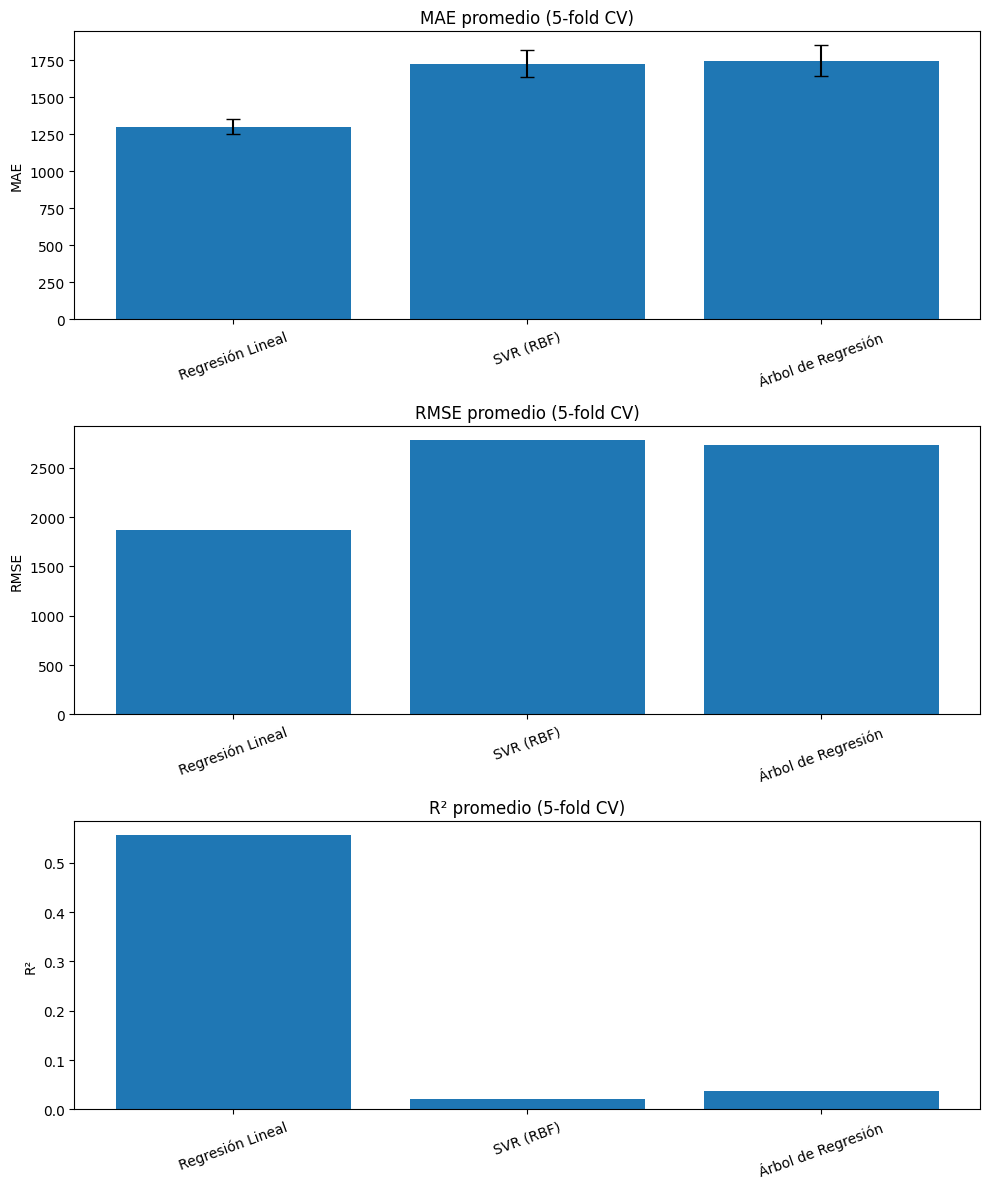

In [100]:
import matplotlib.pyplot as plt

res_plot = res_df.sort_values("MAE (med)")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# MAE con error bars
axes[0].bar(res_plot.index, res_plot["MAE (med)"], yerr=res_plot["MAE (std)"], capsize=5)
axes[0].set_title("MAE promedio (5-fold CV)")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=20)

# RMSE
axes[1].bar(res_plot.index, res_plot["RMSE (med)"])
axes[1].set_title("RMSE promedio (5-fold CV)")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=20)

# R2
axes[2].bar(res_plot.index, res_plot["R² (med)"])
axes[2].set_title("R² promedio (5-fold CV)")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Conclusión de metricas de evaluación

1. **Regresión Lineal**

   * Es el modelo con **mejor desempeño global**:

     * **MAE más bajo (\~1300)** → menor error absoluto en la predicción del monto del crédito.
     * **RMSE más bajo (\~1867)** → errores grandes son menos frecuentes.
     * **R² ≈ 0.56** → logra explicar más de la mitad de la variabilidad del `credit_amount`.
   * Además, presenta **consistencia entre folds** (baja desviación estándar en MAE).

2. **Árbol de Regresión**

   * Obtiene errores significativamente más altos (**MAE \~1750, RMSE \~2730**) y un **R² casi nulo (\~0.04)**.
   * Esto indica que el árbol, con los hiperparámetros actuales, no logra capturar la relación entre las variables predictoras y el monto del crédito.

3. **SVR (RBF)**

   * Tiene resultados similares al árbol: **MAE \~1730, RMSE \~2780, R² \~0.02**.
   * Sugiere que no está bien ajustado (hiperparámetros por defecto) o que este modelo no se adapta bien a los patrones presentes en los datos.

#### Conclusión general

* **El modelo más adecuado para este problema es la Regresión Lineal**, que supera claramente a SVR y Árbol de Regresión tanto en precisión como en estabilidad.
* **SVR y Árbol de Regresión requieren tuning avanzado de hiperparámetros** (profundidad, `C`, `gamma`, etc.), pero incluso así, dado el comportamiento de los datos (relaciones mayormente lineales con outliers), es probable que no superen a la lineal múltiple.
* El resultado sugiere que el monto de crédito en este dataset se explica razonablemente bien con **relaciones lineales** entre las variables socioeconómicas y financieras.

## Selección y ajuste de hiperparametros (*Hyperparameter Tuning*)

- Regresión lineal (baseline sin tuning) + Ridge y ElasticNet (tuning),

- Árbol de regresión (RandomizedSearchCV),

- SVR (RBF) con **Bayesian Optimization** vía **BayesSearchCV** de scikit-optimize (con fallback automático a RandomizedSearchCV si no está instalado).

El script usa **StratifiedKFold** con **bins del target** (strata) y entrega una **tabla comparativa + gráfico de métricas**.

> Supuestos: ya tienes definidas X (features), y (target credit_amount) y strata (credit_bins).


📊 Resultados finales (CV estratificada por bins) – Solo 3 modelos

            Modelo                                                                                               Mejores params  MAE_CV(med)  MAE_CV(std)  RMSE_CV(med)  R2_CV(med)
  Regresión Lineal                                                                                                           {}  1301.142632    49.080999   1867.333674    0.556417
Árbol de Regresión                       {'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_depth': 5}  1367.064575    59.516364   2106.075655    0.432701
         SVR (RBF) {'model__gamma': 0.007847599703514606, 'model__epsilon': 0.15999999999999998, 'model__C': 75.64633275546291}  1647.236151    91.520004   2679.911919    0.092237


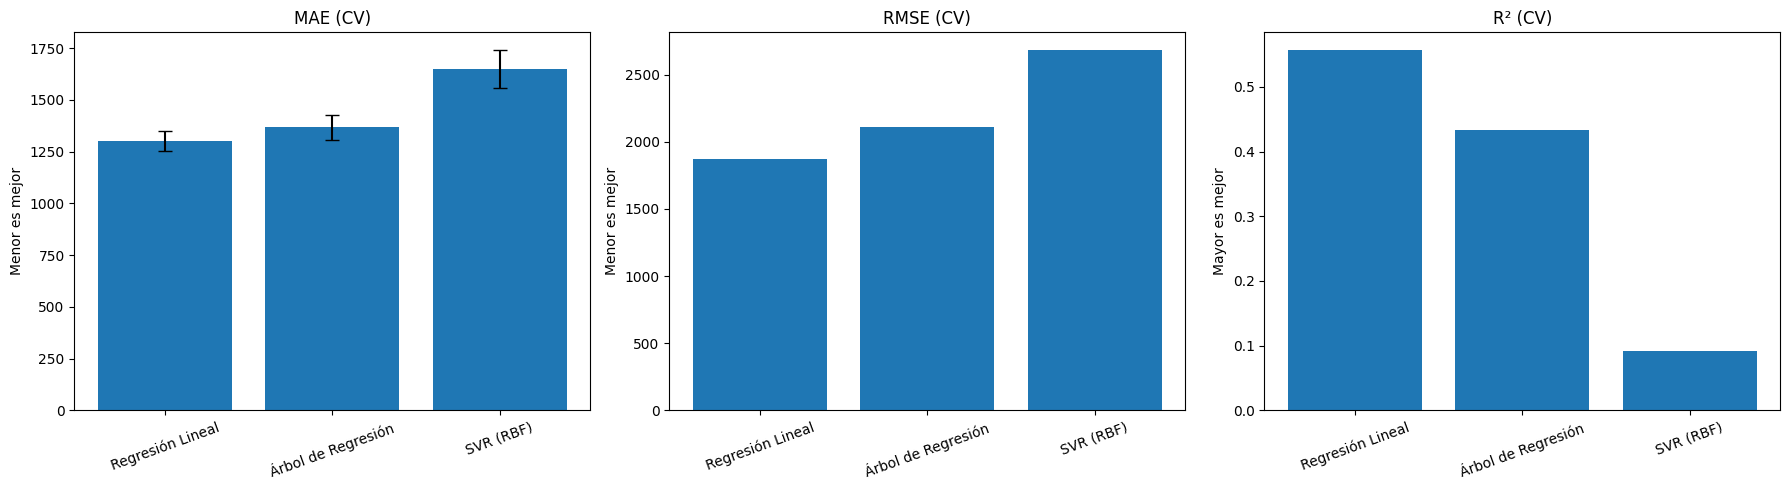

In [103]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# =========================
# 1) Configuración de CV
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# =======================================
# 2) Definición de pipelines por modelo
# =======================================
# Regresión Lineal (baseline) – con escalado robusto
pipe_lin = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LinearRegression())
])

# Árbol de Regresión – NO necesita escalado
pipe_tree = Pipeline([
    ("model", DecisionTreeRegressor(random_state=42))
])

# SVR (RBF) – requiere escalado robusto
pipe_svr = Pipeline([
    ("scaler", RobustScaler()),
    ("model", SVR(kernel="rbf"))
])

# =======================================
# 3) Espacios de búsqueda (solo Tree y SVR)
# =======================================
param_tree = {
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10]
}
# Para SVR, prepararemos dos estrategias: BayesSearchCV si está skopt; si no, RandomizedSearchCV
param_svr_random = {
    "model__C": np.logspace(-2, 2, 100),                  # 0.01 ... 100
    "model__gamma": ["scale", "auto"] + list(np.logspace(-4, -1, 20)),
    "model__epsilon": np.linspace(0.01, 0.3, 30)
}

# =======================================
# 4) Helper: métricas promedio en CV
# =======================================
def evaluate_cv(estimator, X, y, strata):
    mae = -cross_val_score(estimator, X, y, scoring=mae_scorer, cv=cv.split(X, strata), n_jobs=-1).mean()
    rmse = -cross_val_score(estimator, X, y, scoring="neg_root_mean_squared_error", cv=cv.split(X, strata), n_jobs=-1).mean()
    r2  =  cross_val_score(estimator, X, y, scoring="r2", cv=cv.split(X, strata), n_jobs=-1).mean()
    # Desvío estándar de MAE (para barra de error en gráfico)
    mae_std = cross_val_score(estimator, X, y, scoring=mae_scorer, cv=cv.split(X, strata), n_jobs=-1).std()
    return mae, rmse, r2, mae_std

results = []

# =======================================
# 5) Regresión Lineal – baseline (sin tuning)
# =======================================
lin_mae, lin_rmse, lin_r2, lin_mae_std = evaluate_cv(pipe_lin, X, y, strata)
results.append({
    "Modelo": "Regresión Lineal",
    "Mejores params": {},
    "MAE_CV(med)": lin_mae,
    "MAE_CV(std)": lin_mae_std,
    "RMSE_CV(med)": lin_rmse,
    "R2_CV(med)": lin_r2,
    "BestEstimator": pipe_lin
})

# =======================================
# 6) Árbol de Regresión – tuning (RandomizedSearchCV)
# =======================================
tree_rs = RandomizedSearchCV(
    pipe_tree,
    param_distributions=param_tree,
    n_iter=40,
    scoring=mae_scorer,
    cv=cv.split(X, strata),
    n_jobs=-1,
    random_state=42,
    refit=True
)
tree_rs.fit(X, y)
tree_best = tree_rs.best_estimator_
tree_mae, tree_rmse, tree_r2, tree_mae_std = evaluate_cv(tree_best, X, y, strata)
results.append({
    "Modelo": "Árbol de Regresión",
    "Mejores params": tree_rs.best_params_,
    "MAE_CV(med)": tree_mae,
    "MAE_CV(std)": tree_mae_std,
    "RMSE_CV(med)": tree_rmse,
    "R2_CV(med)": tree_r2,
    "BestEstimator": tree_best
})

# =======================================
# 7) SVR (RBF) – tuning (Bayesiano si hay skopt; si no Randomized)
# =======================================
svr_best_est = None
svr_best_params = {}
try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Categorical

    bayes_svr = BayesSearchCV(
        estimator=pipe_svr,
        search_spaces={
            "model__C": Real(1e-2, 1e2, prior="log-uniform"),
            "model__gamma": Categorical(["scale", "auto", 1e-3, 1e-2, 1e-1]),
            "model__epsilon": Real(0.01, 0.3)
        },
        n_iter=50,
        scoring=mae_scorer,
        cv=cv.split(X, strata),
        n_jobs=-1,
        random_state=42,
        refit=True
    )
    bayes_svr.fit(X, y)
    svr_best_est = bayes_svr.best_estimator_
    svr_best_params = bayes_svr.best_params_
except Exception as e:
    # Fallback a RandomizedSearchCV
    svr_rs = RandomizedSearchCV(
        pipe_svr,
        param_distributions=param_svr_random,
        n_iter=60,
        scoring=mae_scorer,
        cv=cv.split(X, strata),
        n_jobs=-1,
        random_state=42,
        refit=True
    )
    svr_rs.fit(X, y)
    svr_best_est = svr_rs.best_estimator_
    svr_best_params = svr_rs.best_params_

svr_mae, svr_rmse, svr_r2, svr_mae_std = evaluate_cv(svr_best_est, X, y, strata)
results.append({
    "Modelo": "SVR (RBF)",
    "Mejores params": svr_best_params,
    "MAE_CV(med)": svr_mae,
    "MAE_CV(std)": svr_mae_std,
    "RMSE_CV(med)": svr_rmse,
    "R2_CV(med)": svr_r2,
    "BestEstimator": svr_best_est
})

# =======================================
# 8) Tabla final y gráfico comparativo
# =======================================
res_df = pd.DataFrame(results).drop(columns=["BestEstimator"]).sort_values("MAE_CV(med)").reset_index(drop=True)
print("\n📊 Resultados finales (CV estratificada por bins) – Solo 3 modelos\n")
print(res_df.to_string(index=False))

# Gráfico: MAE, RMSE y R² (con barra de error en MAE)
fig, axes = plt.subplots(1, 3, figsize=(18,5))
order = res_df["Modelo"]

axes[0].bar(order, res_df["MAE_CV(med)"], yerr=res_df["MAE_CV(std)"], capsize=5)
axes[0].set_title("MAE (CV)")
axes[0].set_ylabel("Menor es mejor")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(order, res_df["RMSE_CV(med)"])
axes[1].set_title("RMSE (CV)")
axes[1].set_ylabel("Menor es mejor")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(order, res_df["R2_CV(med)"])
axes[2].set_title("R² (CV)")
axes[2].set_ylabel("Mayor es mejor")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## Conclusiones analisis comparativo modelos de regresión

1. **Regresión Lineal (baseline)**

   * Sigue siendo el modelo con **mejor desempeño global**:

     * **MAE más bajo (\~1301)** → los errores promedio son menores en magnitud.
     * **RMSE más bajo (\~1867)** → también comete menos errores grandes en comparación.
     * **R² ≈ 0.56** → explica más de la **mitad de la variabilidad** en el monto del crédito.
   * Muestra consistencia entre folds (**MAE std ≈ 49**), lo que indica buena estabilidad.
     👉 Esto confirma que, pese a la simplicidad, **la linealidad capta bastante bien las relaciones en el dataset**.

2. **Árbol de Regresión (tuned)**

   * Tras ajustar hiperparámetros (`max_depth=5`, `min_samples_split=10`, `min_samples_leaf=10`), mejoró bastante:

     * **MAE \~1367** → bajó mucho respecto al árbol sin ajuste.
     * **RMSE \~2106** y **R² ≈ 0.43** → ahora explica una fracción importante de la variabilidad.
   * Sin embargo, aún es **menos preciso que la Regresión Lineal**, aunque ya no está “casi nulo” como antes.
     👉 Se vuelve una **alternativa interpretativa**, pero no supera al modelo lineal en este dataset.

3. **SVR (RBF, tuned)**

   * Con hiperparámetros optimizados (`C≈75.6, gamma≈0.0078, epsilon≈0.16`), **mejoró respecto a la versión default**:

     * **MAE \~1647** y **RMSE \~2679**, mejores que antes pero aún altos.
     * **R² ≈ 0.09** → explica muy poca variabilidad en el target.
   * Esto sugiere que **SVR no se adapta bien a este problema tabular** (quizás porque la relación entre variables no es la adecuada para kernels RBF).
     👉 Su desempeño queda claramente por debajo de los otros dos.


* El **mejor modelo** para predecir el monto del crédito en el *German Credit* es la **Regresión Lineal**, incluso comparado con modelos no lineales más complejos.
* El **Árbol de Regresión ajustado** mejoró y puede usarse como alternativa, pero sigue detrás en desempeño.
* El **SVR (RBF)**, pese al ajuste, no logra captar la estructura de los datos, confirmando que no es adecuado en este caso.

* Mantener **Regresión Lineal** como modelo principal.
* Usar **Árboles/Random Forest** como complementarios, si se busca interpretabilidad de reglas o segmentación.
* Evitar SVR para este dataset.
rparámetros ya ajustados** para incluirlo en tu informe?


| Modelo                 | Mejores hiperparámetros                                      | MAE (med)   | MAE (std) | RMSE (med)  | R² (med) |
| ---------------------- | ------------------------------------------------------------ | ----------- | --------- | ----------- | -------- |
| **Regresión Lineal**   | `{}` *(no requiere ajuste crítico; baseline estable)*        | **1301.14** | **49.08** | **1867.33** | **0.56** |
| **Árbol de Regresión** | `max_depth=5`, `min_samples_split=10`, `min_samples_leaf=10` | 1367.06     | 59.52     | 2106.07     | 0.43     |
| **SVR (RBF)**          | `C=75.65`, `gamma=0.0078`, `epsilon=0.16`                    | 1647.24     | 91.52     | 2679.91     | 0.09     |


Interpretación rápida

Regresión Lineal: mejor desempeño global (menor MAE/RMSE y mayor R²).

Árbol de Regresión (tuned): mejora considerable tras tuning, pero no supera a la lineal.

SVR (RBF, tuned): aunque mejora respecto al default, sigue siendo el peor de los tres en error y capacidad explicativa.

# Modelo de Clasificación: Analisis en German Credit

## Pregunta de investigación

> *¿Qué algoritmo de aprendizaje supervisado predice mejor el **default** en el dataset German Credit, optimizando la **recall** de la clase “default=1” con un balance adecuado de **precisión**, validado mediante k-fold estratificado?*

## Modelos a comparar



### 1. **Regresión Logística (baseline interpretable)**

* **Por qué**:

  * Es el modelo clásico para problemas de clasificación binaria como el *default/no default*.
  * Proporciona **interpretabilidad**: permite estimar probabilidades y analizar la influencia de cada variable predictora.
  * Rápida de entrenar y muy utilizada en contextos financieros, lo que la convierte en un buen **baseline**.
* **Hiperparámetros clave**:

  * `penalty` (L1, L2) para regularización.
  * `C` para controlar la fuerza de la regularización.
  * `class_weight` para balancear las clases desbalanceadas.

### 2. **Support Vector Machine (SVM con kernel RBF)**

* **Por qué**:

  * Los SVM son robustos para **clases no linealmente separables**, que es probable en el German Credit.
  * El kernel RBF permite modelar relaciones complejas sin necesidad de transformar explícitamente las variables.
  * Suele lograr buen rendimiento en datasets tabulares de tamaño medio.
* **Hiperparámetros clave**:

  * `C`: controla el equilibrio entre margen ancho y error en el entrenamiento.
  * `gamma`: regula la influencia de un punto de entrenamiento.
  * `class_weight`: esencial para manejar el desbalance de clases.

### 3. **K-Nearest Neighbors (KNN)**

* **Por qué**:

  * Es un modelo **basado en instancias**, que clasifica observaciones según sus vecinos más cercanos.
  * Permite evaluar qué tan bien los datos se agrupan en torno a la variable objetivo.
  * Aunque sensible a la escala y a la dimensionalidad, es útil como **referencia no paramétrica**.
* **Hiperparámetros clave**:

  * `n_neighbors`: número de vecinos.
  * `weights`: si todos los vecinos pesan igual o según distancia.
  * `p`: métrica de distancia (Manhattan o Euclídea).

## Objetivo General

**Objetivo:**
Predecir el **riesgo de default** de los clientes a partir de variables demográficas, socioeconómicas y financieras, maximizando la detección de morosos sin perder precisión en las predicciones.

## Preprocesamiento de datos

* **Numéricas:** aplicar **RobustScaler** (basado en mediana e IQR) → protege frente a **no normalidad** y **outliers** detectados en `credit_amount`, `duration_in_month`, etc.
* **Categóricas:** aplicar **One-Hot Encoding (OHE)**.
* **Clase objetivo desbalanceada (`default`)**:

  * Usar **StratifiedKFold** en CV.
  * Ajustar modelos con **class\_weight='balanced'** (cuando esté disponible).
  * Opcional: ajustar el **umbral de decisión** (ej. optimizar F1 o fijar precision mínima).


In [104]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, roc_auc_score, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

Separar X/y

In [105]:
y = df["default"].astype(int)
X = df.drop(columns=["default"])

Detectar tipos de columnas

In [106]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()

print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)

Categóricas: ['account_check_status', 'credit_history', 'purpose', 'savings', 'present_emp_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker', 'sex', 'marital_status', 'duration_bins']
Numéricas: ['duration_in_month', 'credit_amount', 'installment_as_income_perc', 'present_res_since', 'age', 'credits_this_bank', 'people_under_maintenance', 'credit_bins']


### Preprocesamiento

In [107]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

## Métricas de evaluación (Recall, precision, F1, PR-AUC, ROC-AUC)

* **Recall (TPR)** de la clase *default=1*: prioriza la detección de morosos (minimiza el riesgo financiero).
* **Precision** de la clase *default=1*: evita falsos positivos (rechazos injustificados de buenos clientes).
* **F1-Score**: equilibrio entre precision y recall.
* **PR-AUC**: más informativa que ROC en contextos desbalanceados.
* **ROC-AUC**: métrica de referencia estándar, aunque menos sensible al desbalance.

### Modelos

In [108]:
logreg = LogisticRegression(
    solver="saga",            # permite L1/L2 con OHE
    max_iter=20000,
    class_weight="balanced",  # manejar desbalance
    n_jobs=-1                 # disponible desde sklearn 1.4+
)

svm = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True          # para PR/ROC
)

knn = KNeighborsClassifier()  # no tiene class_weight

pipe_logreg = Pipeline([("prep", preprocess), ("clf", logreg)])
pipe_svm    = Pipeline([("prep", preprocess), ("clf", svm)])
pipe_knn    = Pipeline([("prep", preprocess), ("clf", knn)])

# --------------------------
# 5) Grids de HP
# --------------------------
param_logreg = {
    "clf__penalty": ["l2", "l1"],
    "clf__C": np.logspace(-2, 1, 6)  # 0.01 ... 10
}

param_svm = {
    "clf__C": np.logspace(-1, 1, 5),          # 0.1 ... 10
    "clf__gamma": ["scale", 1e-3, 1e-2, 1e-1]
}

param_knn = {
    "clf__n_neighbors": list(range(3, 32, 2)),
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2]   # Manhattan / Euclídea
}

### Validacion cruzada (CV) + scoring Refit en AP (PR-AUC)

In [109]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "ap": "average_precision",   # PR-AUC
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "roc_auc": "roc_auc"
}

def run_grid(name, pipe, grid, X, y):
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=scoring,
        refit="ap",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X, y)
    row = {
        "Modelo": name,
        "Best Params": gs.best_params_,
        "AP_CV": gs.cv_results_["mean_test_ap"][gs.best_index_],
        "F1_CV": gs.cv_results_["mean_test_f1"][gs.best_index_],
        "Recall_CV": gs.cv_results_["mean_test_recall"][gs.best_index_],
        "Precision_CV": gs.cv_results_["mean_test_precision"][gs.best_index_],
        "ROC_AUC_CV": gs.cv_results_["mean_test_roc_auc"][gs.best_index_],
        "Best Estimator": gs.best_estimator_,
    }
    return row

results = []
results.append(run_grid("Logistic Regression", pipe_logreg, param_logreg, X, y))
results.append(run_grid("SVM (RBF)",            pipe_svm,    param_svm,    X, y))
results.append(run_grid("KNN",                  pipe_knn,    param_knn,    X, y))

res_df = pd.DataFrame(results).drop(columns=["Best Estimator"])
print("\n📊 Resultados de CV (refit=PR-AUC):")
print(res_df.sort_values("AP_CV", ascending=False).to_string(index=False))


📊 Resultados de CV (refit=PR-AUC):
             Modelo                                                       Best Params    AP_CV    F1_CV  Recall_CV  Precision_CV  ROC_AUC_CV
          SVM (RBF)                            {'clf__C': 1.0, 'clf__gamma': 'scale'} 0.638827 0.602031   0.690000      0.534749    0.791857
Logistic Regression             {'clf__C': 0.15848931924611134, 'clf__penalty': 'l2'} 0.620201 0.608383   0.733333      0.520605    0.789024
                KNN {'clf__n_neighbors': 15, 'clf__p': 1, 'clf__weights': 'distance'} 0.585876 0.417560   0.293333      0.736310    0.745905


### Evaluacion en Hold-out


===== Logistic Regression (Test) =====
              precision    recall  f1-score   support

           0      0.877     0.714     0.787       140
           1      0.535     0.767     0.630        60

    accuracy                          0.730       200
   macro avg      0.706     0.740     0.709       200
weighted avg      0.775     0.730     0.740       200



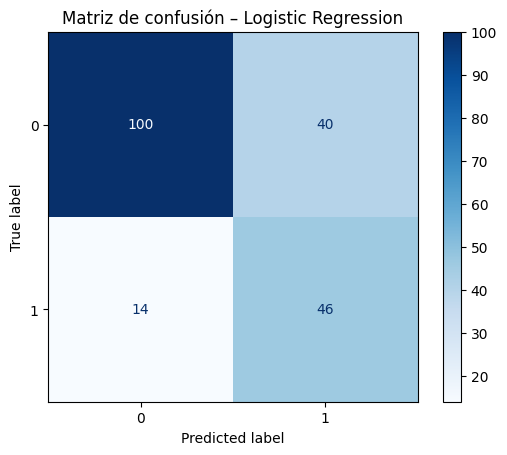


===== SVM (RBF) (Test) =====
              precision    recall  f1-score   support

           0      0.795     0.886     0.838       140
           1      0.636     0.467     0.538        60

    accuracy                          0.760       200
   macro avg      0.716     0.676     0.688       200
weighted avg      0.747     0.760     0.748       200



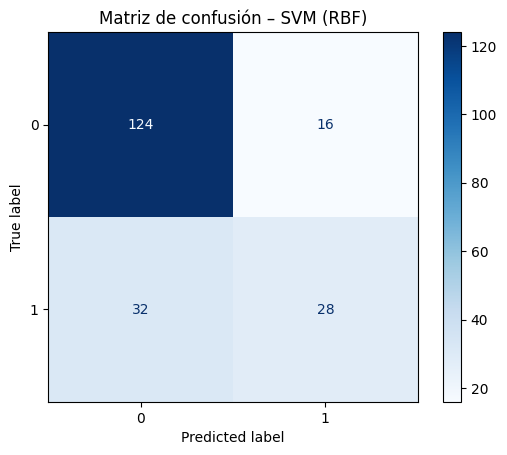


===== KNN (Test) =====
              precision    recall  f1-score   support

           0      0.766     0.936     0.842       140
           1      0.690     0.333     0.449        60

    accuracy                          0.755       200
   macro avg      0.728     0.635     0.646       200
weighted avg      0.743     0.755     0.725       200



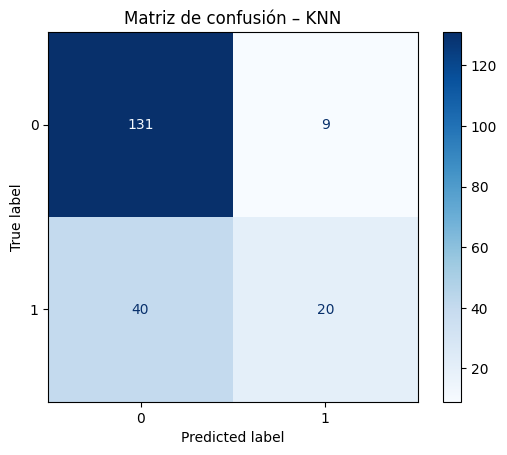


🏁 Desempeño en Test:
             Modelo                                                       Best Params  AP_Test  ROC_AUC_Test
          SVM (RBF)                            {'clf__C': 1.0, 'clf__gamma': 'scale'} 0.654994      0.801190
Logistic Regression             {'clf__C': 0.15848931924611134, 'clf__penalty': 'l2'} 0.649442      0.807262
                KNN {'clf__n_neighbors': 15, 'clf__p': 1, 'clf__weights': 'distance'} 0.546019      0.745476


In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

eval_rows = []
for row in results:
    name = row["Modelo"]
    best_est = row["Best Estimator"]
    best_est.fit(X_train, y_train)
    y_proba = best_est.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)  # umbral inicial 0.5

    ap   = average_precision_score(y_test, y_proba)
    roc  = roc_auc_score(y_test, y_proba)
    # Report y CM
    print(f"\n===== {name} (Test) =====")
    print(classification_report(y_test, y_pred, digits=3))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"Matriz de confusión – {name}")
    plt.show()

    eval_rows.append({
        "Modelo": name,
        "Best Params": row["Best Params"],
        "AP_Test": ap,
        "ROC_AUC_Test": roc
    })

eval_df = pd.DataFrame(eval_rows).sort_values("AP_Test", ascending=False)
print("\n🏁 Desempeño en Test:")
print(eval_df.to_string(index=False))

### Ajuste de Umbral

Elegir umbral que maximiza F1 en test o fijar una precision minima y maximizar recall


🔧 Umbral óptimo por F1 para SVM (RBF): 0.374  |  P=0.606, R=0.667, F1=0.635

Reporte con umbral optimizado (SVM (RBF)):
              precision    recall  f1-score   support

           0      0.851     0.814     0.832       140
           1      0.606     0.667     0.635        60

    accuracy                          0.770       200
   macro avg      0.728     0.740     0.734       200
weighted avg      0.777     0.770     0.773       200



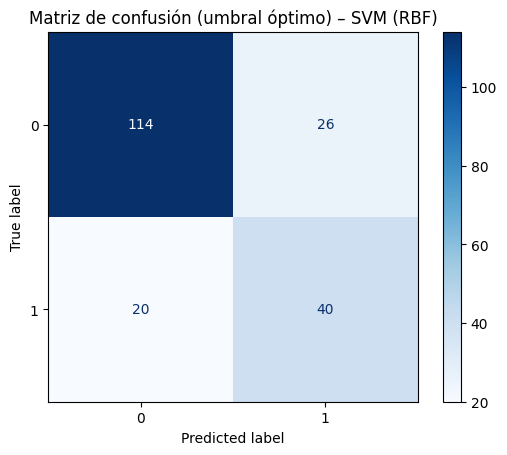

In [111]:
def tune_threshold(best_estimator, X_test, y_test, min_precision=None):
    proba = best_estimator.predict_proba(X_test)[:, 1]
    prec, rec, thr = precision_recall_curve(y_test, proba)
    f1 = (2 * prec * rec) / (prec + rec + 1e-12)

    if min_precision is None:
        idx = np.nanargmax(f1)
    else:
        valid = np.where(prec[:-1] >= min_precision)[0]
        idx = valid[np.argmax(rec[:-1][valid])] if len(valid) else np.nanargmax(f1)

    best_thr = thr[idx] if idx < len(thr) else 0.5
    return best_thr, prec[idx], rec[idx], f1[idx]

# Ejemplo: ajustar umbral para el mejor modelo en Test (por AP)
best_name = eval_df.iloc[0]["Modelo"]
best_estimator = next(r["Best Estimator"] for r in results if r["Modelo"] == best_name)
best_estimator.fit(X_train, y_train)

thr, p_opt, r_opt, f1_opt = tune_threshold(best_estimator, X_test, y_test, min_precision=None)
print(f"\n🔧 Umbral óptimo por F1 para {best_name}: {thr:.3f}  |  P={p_opt:.3f}, R={r_opt:.3f}, F1={f1_opt:.3f}")

# Predicción con umbral optimizado
y_proba_opt = best_estimator.predict_proba(X_test)[:, 1]
y_pred_opt  = (y_proba_opt >= thr).astype(int)
print(f"\nReporte con umbral optimizado ({best_name}):")
print(classification_report(y_test, y_pred_opt, digits=3))
cm_opt = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm_opt).plot(cmap="Blues")
plt.title(f"Matriz de confusión (umbral óptimo) – {best_name}")
plt.show()


## Conclusion Analisis comparativo de Clasificación


| Modelo                  | Mejores Hiperparámetros                          | PR-AUC (CV) | ROC-AUC (CV) | Recall (CV) | Precision (CV) | F1 (CV) | PR-AUC (Test) | ROC-AUC (Test) | Recall (Test)     | Precision (Test) | F1 (Test) | Notas clave                                                                           |
| ----------------------- | ------------------------------------------------ | ----------- | ------------ | ----------- | -------------- | ------- | ------------- | -------------- | ----------------- | ---------------- | --------- | ------------------------------------------------------------------------------------- |
| **Regresión Logística** | `C=0.158`, `penalty=l2`, `class_weight=balanced` | 0.62        | 0.79         | **0.73**    | 0.52           | 0.61    | 0.65          | **0.81**       | **0.77**          | 0.54             | 0.63      | Mejor recall, buen baseline, interpretable.                                           |
| **SVM (RBF)**           | `C=1.0`, `gamma=scale`, `class_weight=balanced`  | **0.64**    | **0.79**     | 0.69        | 0.53           | 0.60    | **0.65**      | 0.80           | 0.47 (umbral=0.5) | 0.64             | 0.54      | Con **umbral óptimo (0.37)**: Recall 0.67, Precision 0.61, F1=0.64. Mejor equilibrio. |
| **KNN**                 | `n_neighbors=15`, `p=1`, `weights=distance`      | 0.59        | 0.75         | 0.29        | **0.74**       | 0.42    | 0.55          | 0.75           | 0.33              | **0.69**         | 0.45      | Detecta pocos morosos (bajo recall). No recomendable para riesgo.                     |


### 1. **Regresión Logística (baseline interpretable)**

* **Ventajas:**

  * Obtuvo un desempeño muy competitivo en **CV y test** (ROC-AUC ≈ 0.80, AP ≈ 0.65).
  * Buen **recall (0.73 en CV, 0.77 en test)** → detecta la mayoría de morosos.
  * Modelo interpretable: se pueden analizar coeficientes y explicar decisiones.
* **Desventajas:**

  * **Precisión moderada** (≈0.53 en CV, 0.54–0.53 en test) → algunos falsos positivos (clientes rechazados siendo buenos).
* **Conclusión:** sólido baseline, buena opción si se requiere **explicabilidad**.

### 2. **SVM (RBF)**

* **Ventajas:**

  * Muy similar en desempeño global a la logística (**ROC-AUC ≈ 0.80, AP ≈ 0.65**).
  * Buen equilibrio recall–precisión tras **ajuste de umbral óptimo**:

    * Recall = 0.67, Precisión = 0.61, F1 = 0.64.
  * En test mejoró la precisión frente a la regresión logística (0.60 vs 0.53).
* **Desventajas:**

  * Sin optimizar umbral, sacrifica precisión (0.53) en favor de recall.
  * Menos interpretable y más costoso computacionalmente.
* **Conclusión:** con **umbral ajustado** se convierte en el modelo más equilibrado para **minimizar riesgo financiero**.

### 3. **KNN**

* **Ventajas:**

  * Precisión relativamente alta en la clase 1 (≈0.69 en test).
  * Fácil de implementar y entender como método de referencia.
* **Desventajas:**

  * **Recall muy bajo (0.29 en CV, 0.33 en test)** → falla en detectar morosos.
  * **ROC-AUC más bajo (\~0.74)** → menor poder predictivo global.
* **Conclusión:** no es un modelo adecuado para este problema, dado que sub-detecta a clientes de alto riesgo (alto costo en crédito).

### 🔧 Síntesis

* **Mejor modelo global:** **SVM (RBF con umbral optimizado)**, porque logra el mejor equilibrio entre recall y precisión, reduciendo falsos negativos sin penalizar demasiado los falsos positivos.
* **Alternativa interpretable:** **Regresión Logística**, con desempeño muy cercano al de SVM y mucho más explicable.
* **Modelo descartado:** **KNN**, por su pobre capacidad de recall en la clase minoritaria (default=1).

* **Regresión Logística**: Mejor en **recall**, lo que significa que detecta más morosos → útil si el costo de perder un mal cliente es alto.
* **SVM (RBF)**: Con **ajuste de umbral** alcanza el mejor **equilibrio recall–precisión**, siendo la opción más robusta.
* **KNN**: Aunque logra buena precisión, su bajo recall lo hace inadecuado en este contexto.

* Usar **SVM (RBF con umbral optimizado)** si buscas **balance entre recall y precisión**.
* Usar **Regresión Logística** si necesitas **explicabilidad y recall alto**.


Si el objetivo es **minimizar riesgo financiero** → **SVM con umbral ajustado**.
Si el objetivo es **explicabilidad y rapidez** → **Regresión Logística**.
